## 인사이트 도출을 위한 시각화

In [414]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [415]:
df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv", index_col=0)
df = df.copy()

In [416]:
# price "$", "," 제거 -> float형태로 변경
df['price'] = (df['price'].str.replace("$", "").str.replace(",","").astype(float))
df['price']

0        200.0
1         82.0
2        765.0
3        139.0
4        130.0
         ...  
37429     72.0
37430     58.0
37431    299.0
37432    200.0
37433     58.0
Name: price, Length: 22308, dtype: float64

In [417]:
rt_map = {"within an hour" : 4, "within a few hours": 3, "within a day":2, "a few days or more":1}

df['host_response_time_num'] = df['host_response_time'].map(rt_map).fillna(0).astype(int)
df['host_response_time_num'].value_counts()

host_response_time_num
4    11645
0     4393
3     3439
2     1957
1      874
Name: count, dtype: int64

In [418]:
# price랑 host_response_rate(호스트 응답률) 상관계수
pearson_corr = df[['price', 'host_response_time_num']].corr()

# 스피어만
spearman_corr = df[["price","host_response_time_num"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                            price  host_response_time_num
price                   1.000000                0.013136
host_response_time_num  0.013136                1.000000
스피어만:                            price  host_response_time_num
price                   1.000000                0.052905
host_response_time_num  0.052905                1.000000


<Axes: xlabel='host_response_time_num', ylabel='price'>

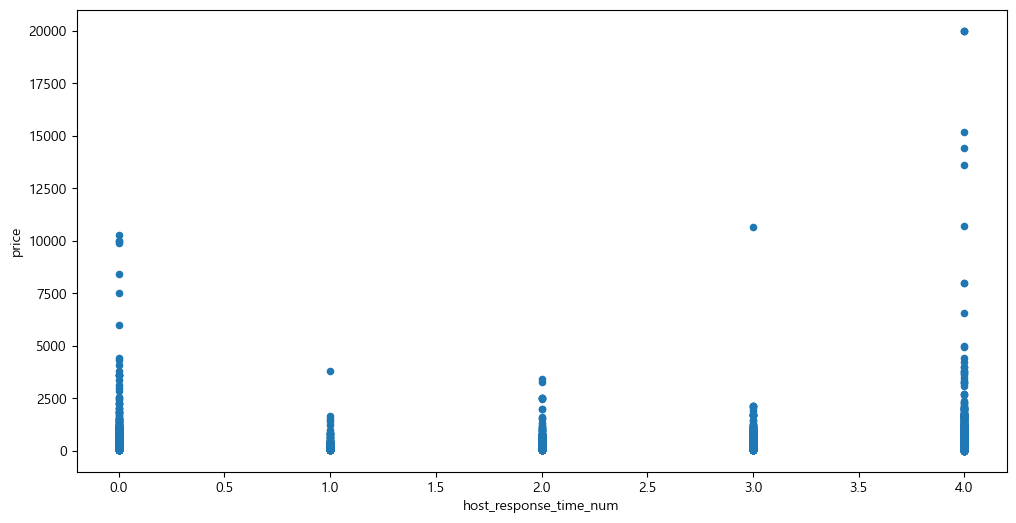

In [419]:
df.plot.scatter(x='host_response_time_num', y='price')

<Axes: title={'center': 'log_price'}, xlabel='host_response_time_num'>

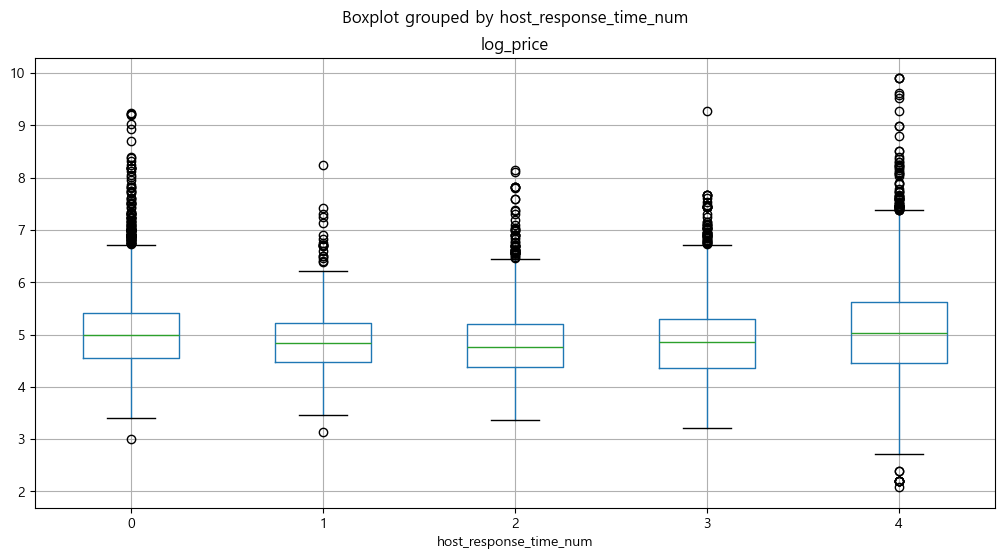

In [420]:
df.assign(log_price=np.log1p(df["price"])).boxplot(column="log_price", by="host_response_time_num")

In [421]:
df['host_response_rate'].isna().sum()
df['host_response_rate'].value_counts(dropna=False)

host_response_rate
100%    12885
NaN      4393
99%       727
98%       562
0%        436
90%       349
68%       305
80%       216
97%       196
92%       182
42%       174
50%       173
94%       150
91%       129
96%       126
95%       104
75%        96
67%        90
79%        90
93%        80
48%        78
89%        68
60%        65
83%        63
86%        57
88%        53
70%        50
82%        35
33%        30
87%        28
25%        26
78%        24
85%        24
40%        22
20%        22
81%        21
41%        21
30%        20
57%        18
71%        15
56%        15
10%         8
74%         7
38%         7
53%         6
34%         6
36%         6
65%         6
17%         5
76%         5
63%         4
46%         4
61%         4
77%         3
14%         2
44%         2
58%         2
29%         2
84%         2
72%         2
73%         2
16%         1
43%         1
55%         1
11%         1
62%         1
Name: count, dtype: int64

In [422]:
# host_response_rate "%" 제거 -> float형태로 변경
df['host_response_rate'] = (df['host_response_rate'].str.replace("%", "").pipe(pd.to_numeric, errors="coerce")) / 100
df['host_response_rate']

0         NaN
1         NaN
2        1.00
3        1.00
4        1.00
         ... 
37429     NaN
37430    1.00
37431    0.94
37432    0.89
37433    1.00
Name: host_response_rate, Length: 22308, dtype: float64

In [423]:
# price랑 host_response_rate(호스트 응답률) 상관계수
# 피어슨
pearson_corr = df[['price', 'host_response_rate']].corr()

# 스피어만
spearman_corr = df[["price","host_response_rate"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                        price  host_response_rate
price               1.000000            0.042325
host_response_rate  0.042325            1.000000
스피어만:                        price  host_response_rate
price               1.000000            0.112934
host_response_rate  0.112934            1.000000


<Axes: xlabel='host_response_rate', ylabel='price'>

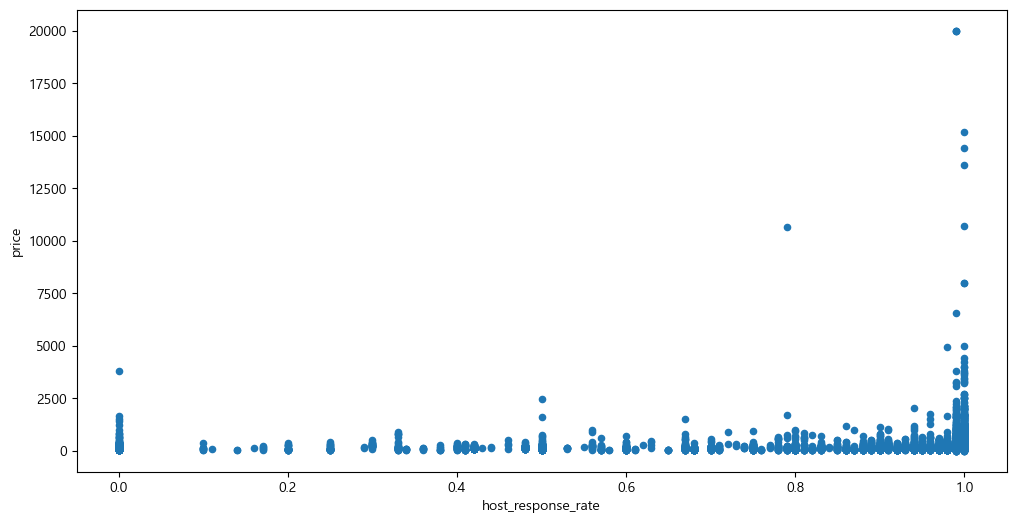

In [424]:
df.plot.scatter(x='host_response_rate', y='price')

In [425]:
#결측치 확인 -- 3466개
df['host_acceptance_rate'].isna().sum()
df['host_acceptance_rate'].value_counts(dropna=False)

host_acceptance_rate
100%    4909
NaN     3466
97%     1407
99%     1006
0%       999
83%      478
77%      473
88%      470
50%      451
96%      396
98%      384
67%      377
91%      374
49%      331
82%      290
84%      270
93%      253
60%      252
94%      247
75%      246
86%      243
95%      232
47%      227
80%      219
92%      218
89%      196
90%      179
72%      172
33%      156
71%      143
70%      137
24%      135
87%      129
73%      127
51%      126
79%      113
81%      110
78%      106
55%       99
58%       98
57%       96
85%       89
56%       84
37%       79
25%       78
74%       76
40%       75
48%       70
69%       67
59%       67
52%       64
68%       62
65%       59
46%       58
41%       58
61%       56
76%       53
43%       52
63%       52
39%       50
62%       49
20%       48
64%       48
53%       46
29%       43
30%       39
17%       35
44%       31
8%        30
23%       28
27%       25
54%       25
11%       23
14%       23
42%       21
32% 

In [426]:
df['host_acceptance_rate'] = (df['host_acceptance_rate'].str.replace("%", "").pipe(pd.to_numeric, errors="coerce")) / 100
df['host_acceptance_rate']

0         NaN
1        1.00
2        0.40
3        0.97
4        1.00
         ... 
37429     NaN
37430    0.80
37431    0.99
37432    1.00
37433    0.80
Name: host_acceptance_rate, Length: 22308, dtype: float64

In [427]:
pearson_corr = df[['price', 'host_acceptance_rate']].corr()

# 스피어만
spearman_corr = df[["price","host_acceptance_rate"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                          price  host_acceptance_rate
price                 1.000000              0.006481
host_acceptance_rate  0.006481              1.000000
스피어만:                         price  host_acceptance_rate
price                 1.00000               0.09998
host_acceptance_rate  0.09998               1.00000


In [428]:
#결측치 확인
df['host_is_superhost'].isna().sum()
df['host_is_superhost'].value_counts(dropna=False)

host_is_superhost
f      15799
t       6135
NaN      374
Name: count, dtype: int64

In [429]:
# 결측치 제외/ t : 1, f : 0 으로 변경
tmp = df[df['host_is_superhost'].notna()].copy()
tmp['host_is_superhost_bool'] = tmp['host_is_superhost'].map({"t":1, "f":0})
tmp['host_is_superhost_bool'].value_counts()

host_is_superhost_bool
0    15799
1     6135
Name: count, dtype: int64

In [430]:
pearson_corr = tmp[['price', 'host_is_superhost_bool']].corr()

# 스피어만
spearman_corr = tmp[["price","host_is_superhost_bool"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                            price  host_is_superhost_bool
price                   1.000000               -0.051083
host_is_superhost_bool -0.051083                1.000000
스피어만:                            price  host_is_superhost_bool
price                   1.000000               -0.067993
host_is_superhost_bool -0.067993                1.000000


<Axes: title={'center': 'log_price'}, xlabel='host_is_superhost_bool'>

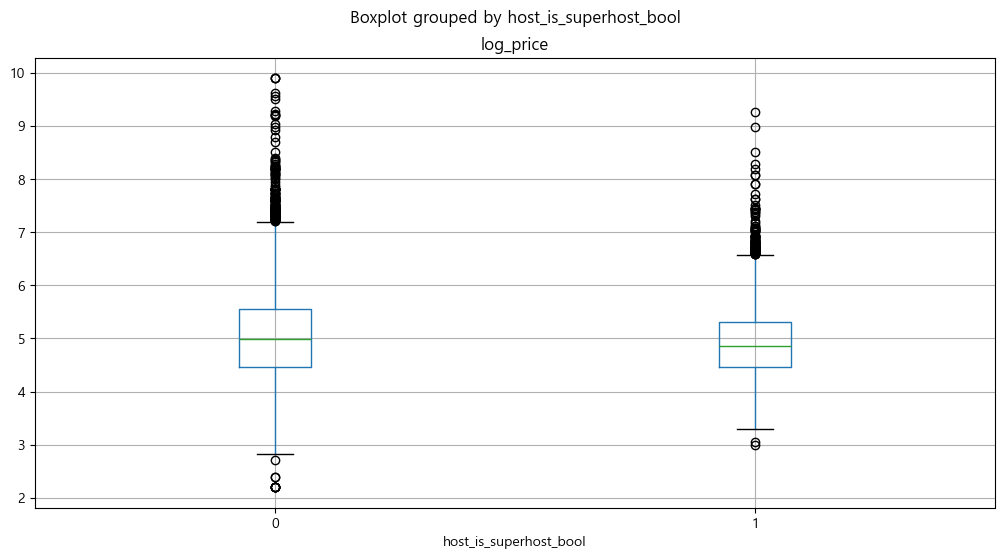

In [431]:
tmp.assign(log_price=np.log1p(tmp["price"])).boxplot(column="log_price", by="host_is_superhost_bool")

In [432]:
tmp.groupby("host_is_superhost_bool")['price'].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost_bool,,,
0,15799,227.760365,146.0
1,6135,178.781255,129.0


In [433]:
# 결측치 확인 
df['host_neighbourhood'].isna().sum()
df['host_neighbourhood'].value_counts(dropna=False)

host_neighbourhood
NaN                                                                                                           4730
Bedford-Stuyvesant                                                                                            1138
Cambridge                                                                                                     1095
Jamaica                                                                                                        834
Williamsburg                                                                                                   756
                                                                                                              ... 
Charleston                                                                                                       1
Center City East                                                                                                 1
Colgate Center                                               

In [434]:
df['host_listings_count'].isna().sum()
df['host_listings_count'].value_counts(dropna=False)

host_listings_count
1.0       6791
2.0       2983
3.0       1588
4.0       1096
5255.0    1094
          ... 
187.0        1
270.0        1
328.0        1
114.0        1
60.0         1
Name: count, Length: 110, dtype: int64

In [435]:
df['host_total_listings_count']

0           3.0
1           1.0
2           3.0
3           1.0
4           2.0
          ...  
37429       2.0
37430      33.0
37431    1974.0
37432      38.0
37433      33.0
Name: host_total_listings_count, Length: 22308, dtype: float64

In [436]:
# 결측치 확인 
display(df['host_total_listings_count'].isna().sum())
display(df['host_total_listings_count'].value_counts(dropna=False).head(10))

np.int64(20)

host_total_listings_count
1.0       3989
2.0       2847
3.0       2029
4.0       1411
5458.0    1094
5.0       1048
6.0        794
7.0        607
8.0        490
9.0        397
Name: count, dtype: int64

<Axes: xlabel='host_total_listings_count', ylabel='price'>

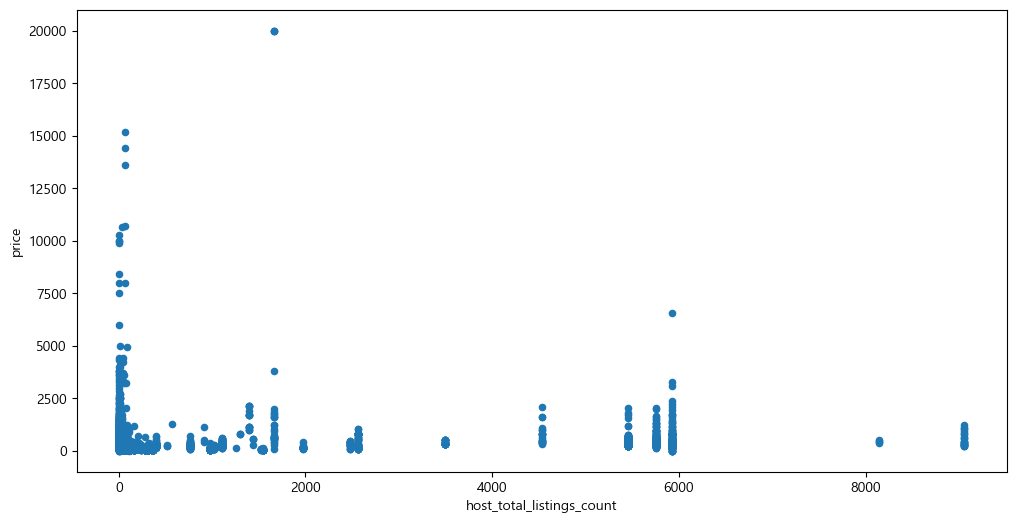

In [437]:
tmp = df[['price', 'host_total_listings_count']].dropna()
tmp.plot.scatter(x="host_total_listings_count", y='price')

In [438]:
# 피어슨/스피어만 확인
# 피어슨
pearson_corr = tmp[['price', 'host_total_listings_count']].corr()

# 스피어만
spearman_corr = tmp[["price","host_total_listings_count"]].corr(method="spearman")
print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                               price  host_total_listings_count
price                      1.000000                   0.160511
host_total_listings_count  0.160511                   1.000000
스피어만:                              price  host_total_listings_count
price                      1.00000                    0.08538
host_total_listings_count  0.08538                    1.00000


In [439]:
display(df['host_verifications'].isna().sum())
display(df['host_verifications'].value_counts(dropna=False))

np.int64(20)

host_verifications
['email', 'phone']                  16852
['email', 'phone', 'work_email']     3230
['phone']                            2138
['phone', 'work_email']                60
NaN                                    20
['email']                               6
[]                                      2
Name: count, dtype: int64

In [440]:
display(df['host_has_profile_pic'].isna().sum())
display(df['host_has_profile_pic'].value_counts(dropna=False).head(10))

np.int64(20)

host_has_profile_pic
t      21646
f        642
NaN       20
Name: count, dtype: int64

In [441]:
tmp = df[df['host_has_profile_pic'].notna()].copy()
tmp['host_has_profile_pic_bool'] = tmp['host_has_profile_pic'].map({"t":1, "f":0})
tmp['host_has_profile_pic_bool'].value_counts()

host_has_profile_pic_bool
1    21646
0      642
Name: count, dtype: int64

In [442]:
pearson_corr = tmp[['price', 'host_has_profile_pic_bool']].corr()

# 스피어만
spearman_corr = tmp[["price","host_has_profile_pic_bool"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                               price  host_has_profile_pic_bool
price                      1.000000                  -0.004845
host_has_profile_pic_bool -0.004845                   1.000000
스피어만:                               price  host_has_profile_pic_bool
price                      1.000000                  -0.001818
host_has_profile_pic_bool -0.001818                   1.000000


In [443]:
# 결측치 확인하기
display(df['host_identity_verified'].isna().sum())
display(df['host_identity_verified'].value_counts(dropna=False).head(10))

np.int64(20)

host_identity_verified
t      20423
f       1865
NaN       20
Name: count, dtype: int64

In [444]:
# 결측치 제외하고 , t/f 0이랑 1로 바꾸기
tmp = df[df['host_identity_verified'].notna()].copy()
tmp['host_identity_verified_bool'] = tmp['host_identity_verified'].map({"t":1, "f":0})
tmp['host_identity_verified_bool'].value_counts()

host_identity_verified_bool
1    20423
0     1865
Name: count, dtype: int64

In [445]:
# 피어슨/스피어만 확인
# 피어슨
pearson_corr = tmp[['price', 'host_identity_verified_bool']].corr()

# 스피어만
spearman_corr = tmp[["price","host_identity_verified_bool"]].corr(method="spearman")

print("피어슨:", pearson_corr)
print("스피어만:", spearman_corr)

피어슨:                                 price  host_identity_verified_bool
price                        1.000000                     0.025129
host_identity_verified_bool  0.025129                     1.000000
스피어만:                                price  host_identity_verified_bool
price                        1.00000                      0.06335
host_identity_verified_bool  0.06335                      1.00000


<Axes: title={'center': 'log_price'}, xlabel='host_identity_verified_bool'>

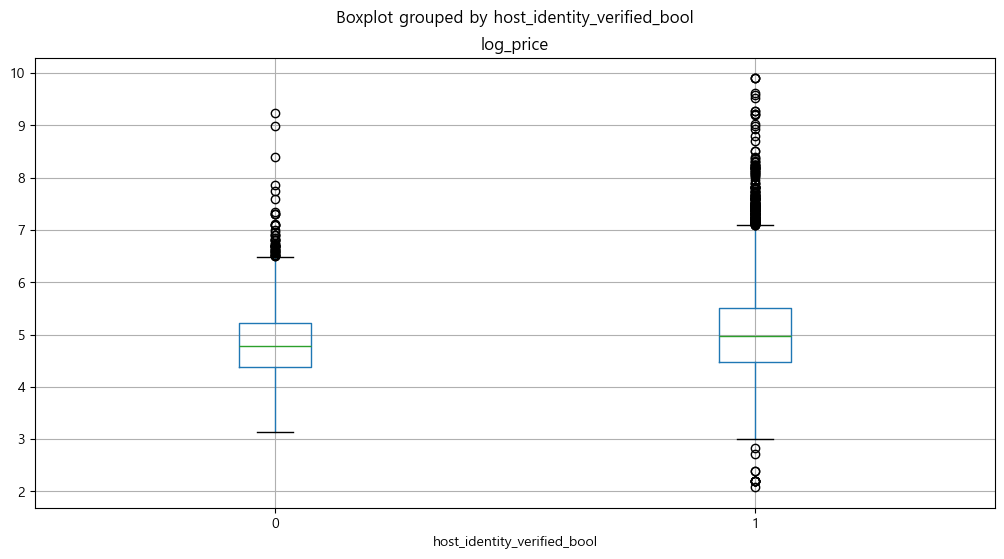

In [446]:
tmp.assign(log_price=np.log1p(tmp["price"])).boxplot(column="log_price", by="host_identity_verified_bool")

In [447]:
display(df['neighbourhood'].isna().sum())
display(df['neighbourhood'].value_counts(dropna=False, normalize=True).head(10))

np.int64(10046)

neighbourhood
Neighborhood highlights    0.549668
NaN                        0.450332
Name: proportion, dtype: float64

In [448]:
display(df['neighbourhood_cleansed'].isna().sum())
display(df['neighbourhood_cleansed'].value_counts(dropna=False).head(10))

np.int64(0)

neighbourhood_cleansed
Bedford-Stuyvesant    1545
Midtown               1461
Upper East Side       1042
Hell's Kitchen        1036
Harlem                1031
Upper West Side        929
Williamsburg           853
Bushwick               758
Crown Heights          648
Chelsea                520
Name: count, dtype: int64

In [449]:
tmp = df.copy()
tmp["log_price"] = np.log1p(tmp['price'])

top15_list = tmp['neighbourhood_cleansed'].value_counts().head(15).index
top15 = tmp[tmp['neighbourhood_cleansed'].isin(top15_list)]

<Axes: title={'center': 'log_price'}, xlabel='neighbourhood_cleansed'>

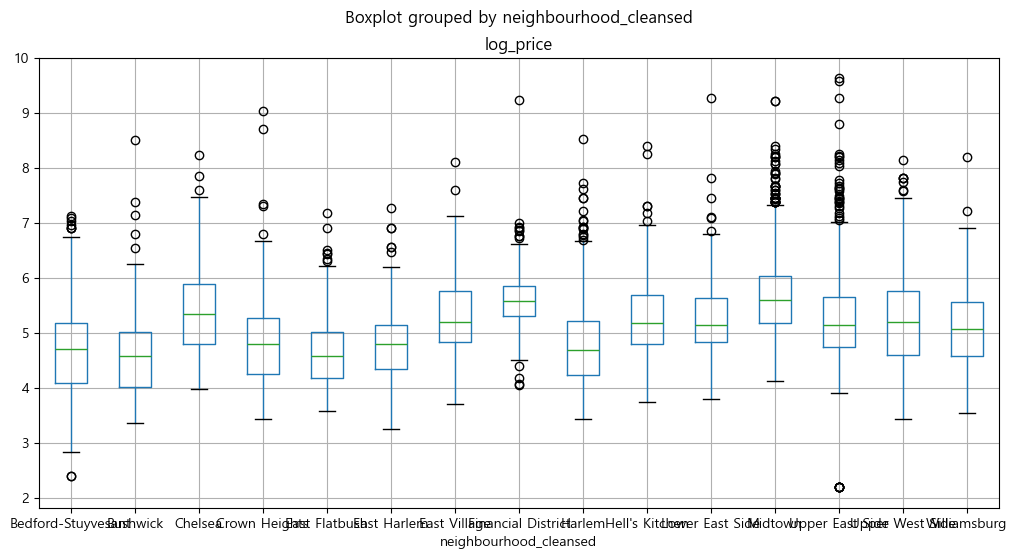

In [450]:

top15.boxplot(column="log_price", by="neighbourhood_cleansed")

In [451]:
df[['price', 'latitude']].corr()

,price,latitude
price,1.000000,0.030858
latitude,0.030858,1.000000


<Axes: xlabel='latitude', ylabel='price'>

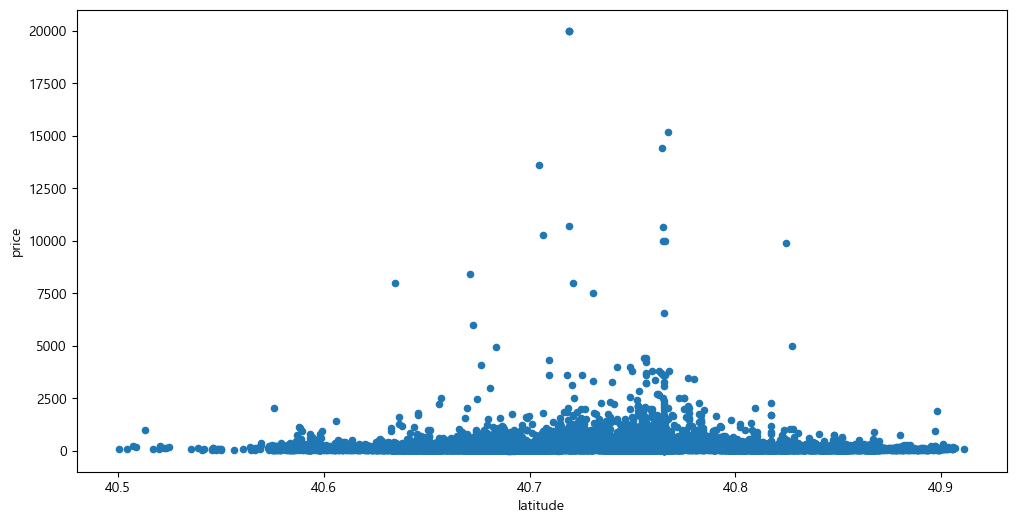

In [452]:
df.plot.scatter(x='latitude', y='price')

In [453]:
df[['price', 'host_total_listings_count']].corr()

,price,host_total_listings_count
price,1.000000,0.160511
host_total_listings_count,0.160511,1.000000


In [454]:
df[["price","host_total_listings_count"]].corr(method="spearman")

,price,host_total_listings_count
price,1.00000,0.08538
host_total_listings_count,0.08538,1.00000


<Axes: xlabel='host_total_listings_count', ylabel='price'>

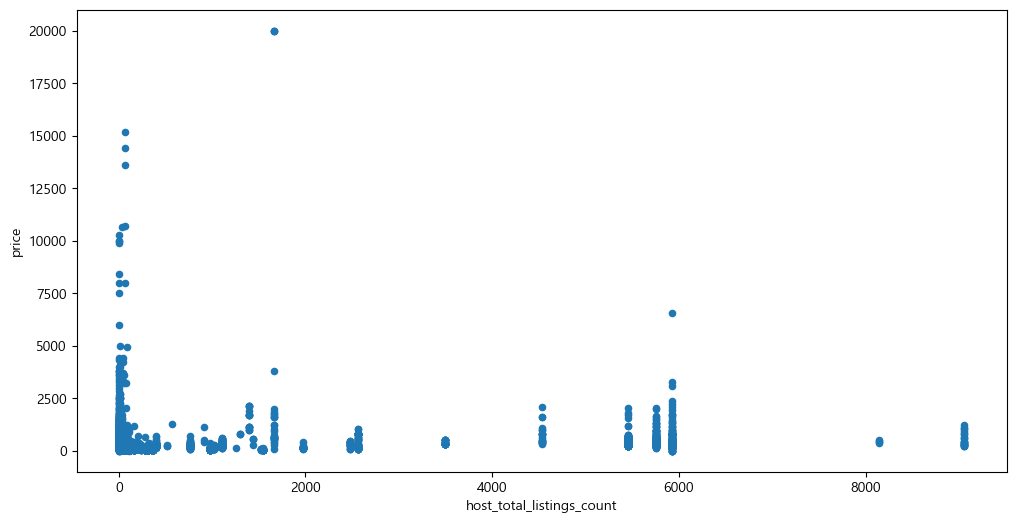

In [455]:
df.plot.scatter(x='host_total_listings_count', y='price')

In [456]:
df[['price', 'host_listings_count']].corr()

,price,host_listings_count
price,1.000000,0.146147
host_listings_count,0.146147,1.000000


In [457]:
df[["price","host_listings_count"]].corr(method="spearman")

,price,host_listings_count
price,1.00000,0.07623
host_listings_count,0.07623,1.00000


<Axes: xlabel='host_listings_count', ylabel='price'>

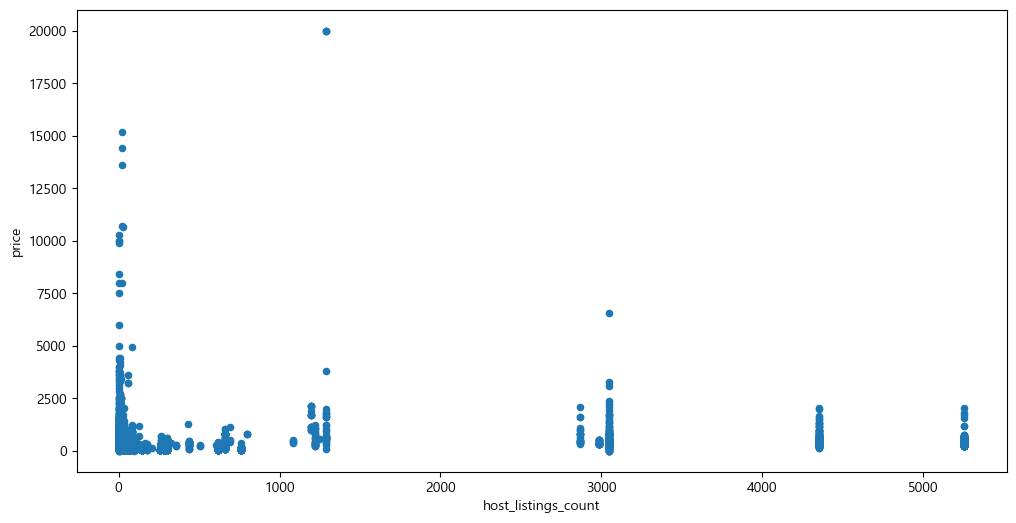

In [458]:
df.plot.scatter(x='host_listings_count', y='price')

In [459]:
df['host_identity_verified'].isna().sum()
df['host_identity_verified'].value_counts(dropna=False)

host_identity_verified
t      20423
f       1865
NaN       20
Name: count, dtype: int64

In [460]:
tmp = df[df['host_identity_verified'].notna()].copy()
tmp['host_identity_verified_bool'] = tmp['host_identity_verified'].map({"t":1, "f":0})
tmp['host_identity_verified_bool'] 

0        1
1        1
2        1
3        1
4        1
        ..
37429    1
37430    1
37431    1
37432    1
37433    1
Name: host_identity_verified_bool, Length: 22288, dtype: int64

In [461]:
tmp[['price', 'host_identity_verified_bool']].corr()

,price,host_identity_verified_bool
price,1.000000,0.025129
host_identity_verified_bool,0.025129,1.000000


In [462]:
tmp[["price","host_identity_verified_bool"]].corr(method="spearman")

,price,host_identity_verified_bool
price,1.00000,0.06335
host_identity_verified_bool,0.06335,1.00000


<Axes: xlabel='host_identity_verified_bool', ylabel='price'>

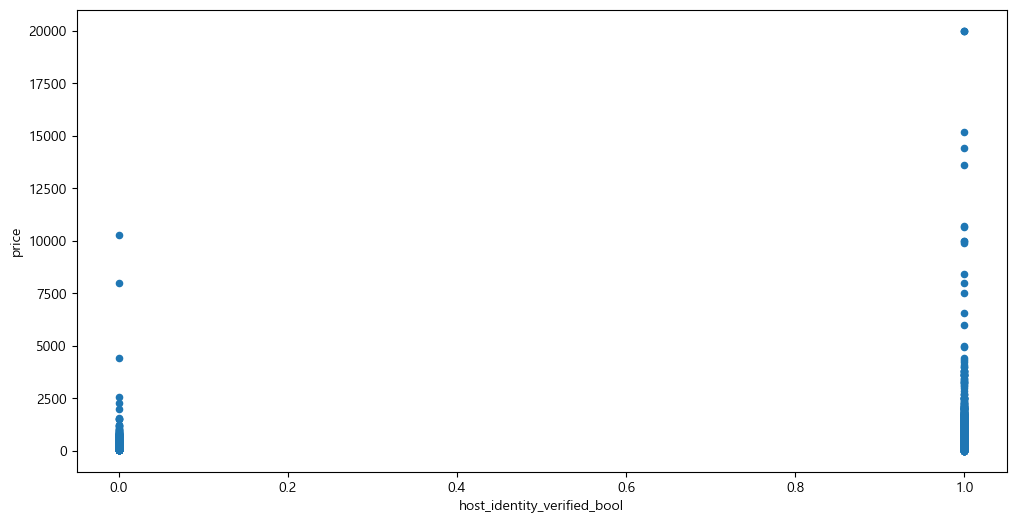

In [463]:
tmp.plot.scatter(x='host_identity_verified_bool', y='price')

<Axes: title={'center': 'log_price'}, xlabel='host_identity_verified_bool'>

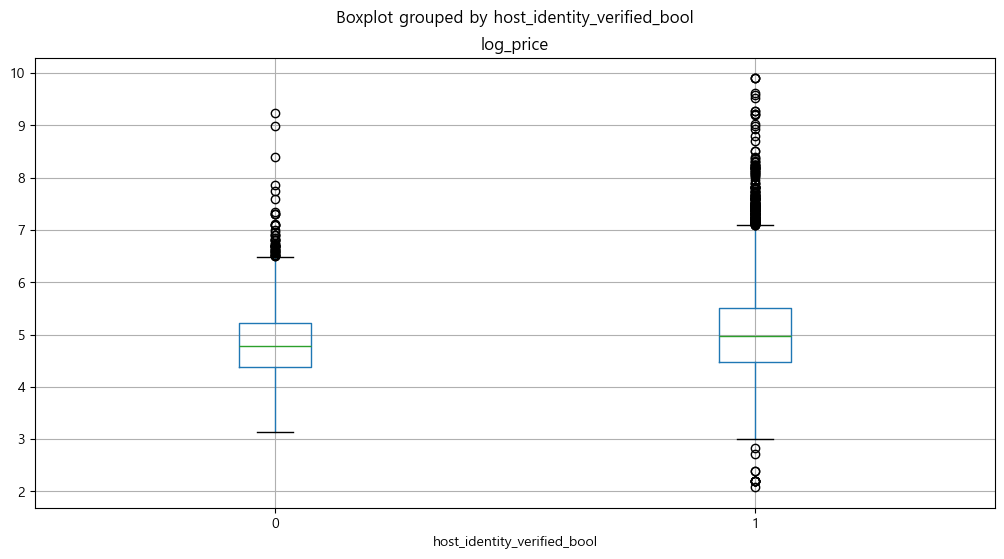

In [464]:
tmp.assign(log_price=np.log1p(tmp["price"])).boxplot(column="log_price", by="host_identity_verified_bool")

In [465]:
tmp.groupby("host_identity_verified_bool")["price"].agg(["count","mean","median"])

,count,mean,median
host_identity_verified_bool,,,
0,1865,178.304021,119.0
1,20423,217.122509,143.0


In [466]:
df.sort_values("price", ascending=False)[["host_id","neighbourhood_cleansed","host_is_superhost", "room_type", "price"]].head(10)  # 상위 10개

,host_id,neighbourhood_cleansed,host_is_superhost,room_type,price
27926,326084746,SoHo,f,Private room,20000.0
27927,326084746,SoHo,f,Private room,20000.0
27925,326084746,SoHo,f,Private room,20000.0
28168,34906299,Upper East Side,f,Entire home/apt,15200.0
28167,34906299,Upper East Side,f,Entire home/apt,14399.0
23309,34906299,Battery Park City,f,Entire home/apt,13600.0
27845,34906299,Lower East Side,f,Entire home/apt,10688.0
29905,252866861,Upper East Side,t,Entire home/apt,10664.0
19990,57586379,Financial District,f,Entire home/apt,10271.0
26219,76166434,Midtown,f,Entire home/apt,10000.0


In [467]:
df['number_of_reviews']

0          9
1        102
2         43
3        241
4        274
        ... 
37429      0
37430      0
37431      0
37432      0
37433      0
Name: number_of_reviews, Length: 22308, dtype: int64

## 여기까지 수임님 상관관계 시각화

In [468]:
df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv")
test_df = df.copy()

In [469]:
test_df[test_df['host_is_superhost'].isna()]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
257,401,333323,city scrape,Cozy bedroom near Times Square,1 bedroom in a 3 bedroom apartment centrally l...,Hell's Kitchen is a central vibrant neighborho...,1698391,Patrick,2012-02-04,"New York, NY",I am quiet and rarely home. Having lived in He...,within an hour,100%,89%,NaN,Hell's Kitchen,5.0,7.0,"['email', 'phone']",t,t,Neighborhood highlights,Hell's Kitchen,Manhattan,40.762690,-73.993610,Private room in rental unit,Private room,1,1.0,1 bath,1.0,1.0,"[""Oven"", ""Cooking basics"", ""Microwave"", ""Hair ...",$82.00,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,NaN,t,0,12,35,238,2025-03-02,185,6,0,178,5,255,20910.0,2014-12-05,2025-01-18,4.75,4.81,4.58,4.86,4.84,4.94,4.71,NaN,f,3,1,2,0,1.48
405,668,783202,city scrape,Charming First Floor Village Apt off Bleecker,DO NOT REQUEST A BOOKING TIL WE CHAT! SCROLL ...,This is Greenwich Village! The best neighborh...,4129805,Evelyn,2012-11-12,"New York, NY","If you are staying in my city place, we live o...",within an hour,98%,69%,NaN,West Village,9.0,12.0,"['email', 'phone']",t,f,Neighborhood highlights,West Village,Manhattan,40.732770,-74.002670,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,2.0,"[""Oven"", ""Babysitter recommendations"", ""Dedica...",$182.00,1,60,1.0,1.0,60.0,60.0,1.0,60.0,NaN,t,13,37,56,56,2025-03-02,402,51,2,56,51,255,46410.0,2012-12-01,2025-02-19,4.73,4.73,4.68,4.85,4.80,4.98,4.72,Exempt,f,5,5,0,0,2.69
431,715,786685,city scrape,Historic Brownstone dwelling gorgeous garden,"Beautifully spacious rooms with huge, secure w...","This is a wonderful, vibrant neighborhood with...",4147380,Lauren,2012-11-14,"New York, NY",I am a food person and love to meet people fro...,within an hour,100%,100%,NaN,Hamilton Heights,2.0,2.0,"['email', 'phone']",t,t,Neighborhood highlights,Harlem,Manhattan,40.822930,-73.949540,Entire townhouse,Entire home/apt,6,1.0,1 bath,1.0,2.0,"[""Portable fans"", ""Oven"", ""Garden view"", ""Baki...",$270.00,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,NaN,t,16,26,35,255,2025-03-03,217,1,0,194,1,60,16200.0,2013-10-22,2024-08-03,4.89,4.89,4.93,4.96,4.96,4.76,4.80,NaN,f,1,1,0,0,1.57
518,873,1042806,city scrape,My Other Little Guestroom,Warm and Cozy newly renovated bedroom in a fam...,Flushing Queens is a very safe and ethnically ...,2680820,Linda,2012-06-19,"New York, NY",We are a fully vaccinated family of four. We w...,within an hour,100%,97%,NaN,Flushing,2.0,5.0,"['email', 'phone']",t,t,Neighborhood highlights,Flushing,Queens,40.755331,-73.817833,Private room in home,Private room,2,1.0,1 shared bath,1.0,1.0,"[""Fire extinguisher"", ""First aid kit"", ""Keypad...",$81.00,2,38,2.0,4.0,38.0,38.0,3.0,38.0,NaN,t,14,15,25,109,2025-03-03,416,55,0

In [470]:
test_df['price'] = (
    test_df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [471]:
test_df['price'].isna().sum()

np.int64(0)

In [472]:
test_df = test_df[test_df['price'] < 20000]

In [473]:
test_df['number_of_reviews_ltm'].isna().sum()

np.int64(0)

In [474]:
test_df['first_review'].isna().sum()

np.int64(6795)

In [475]:
test_df['price'].corr(test_df['number_of_reviews_ltm'])

np.float64(-0.022315217739780912)

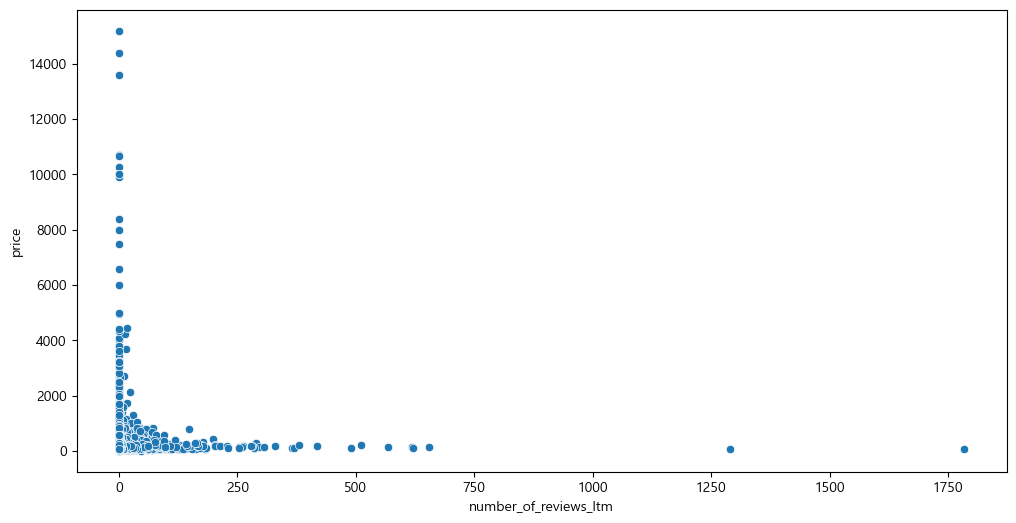

In [476]:
sns.scatterplot(x=test_df['number_of_reviews_ltm'], y=test_df['price'])
plt.show()

In [477]:
test_df['price'].corr(test_df['number_of_reviews_l30d'])

np.float64(-0.014649277003503155)

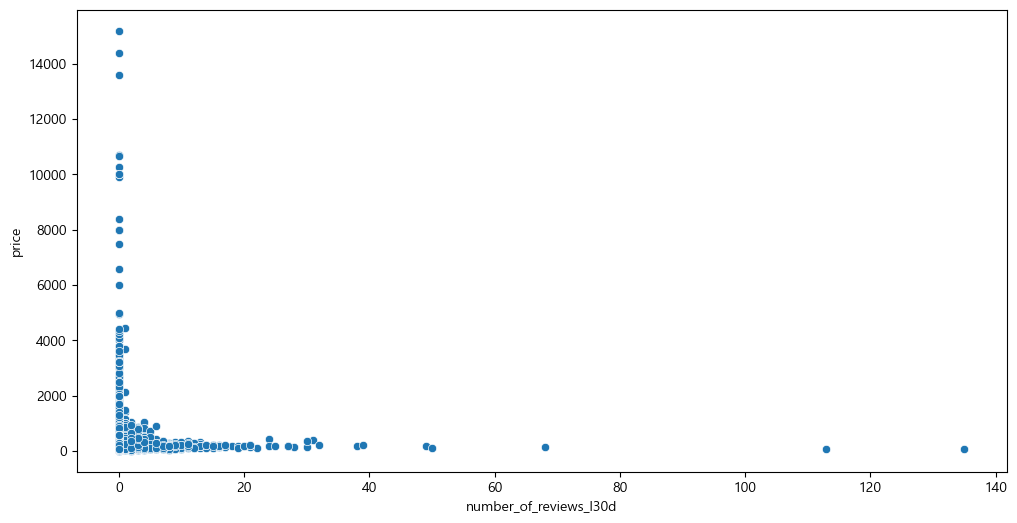

In [478]:
sns.scatterplot(x=test_df['number_of_reviews_l30d'], y=test_df['price'])
plt.show()

In [479]:
test_df['price'].corr(test_df['estimated_occupancy_l365d'])

np.float64(-0.09209115887362244)

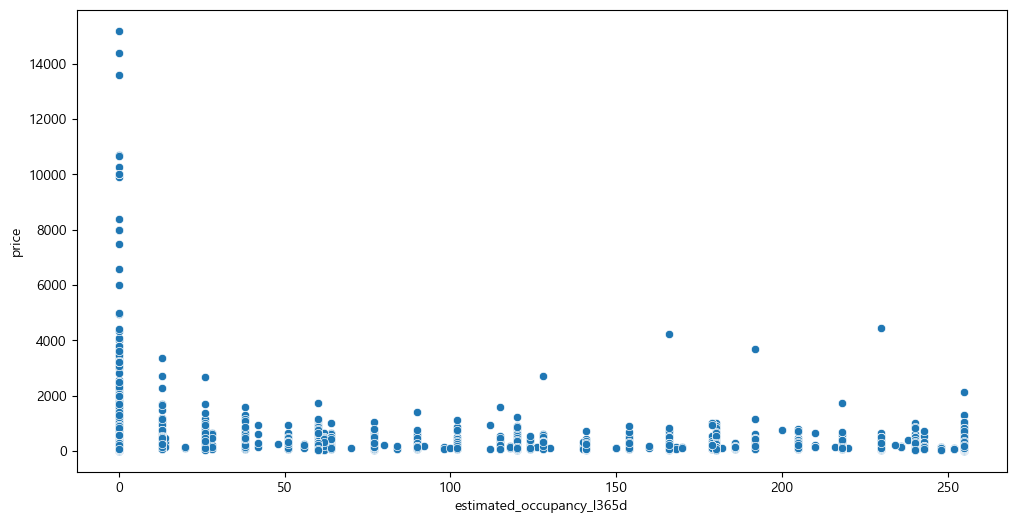

In [480]:
sns.scatterplot(x=test_df['estimated_occupancy_l365d'], y=test_df['price'])
plt.show()

In [481]:
test_df['price'].corr(test_df['review_scores_rating'])

np.float64(0.04395728738180065)

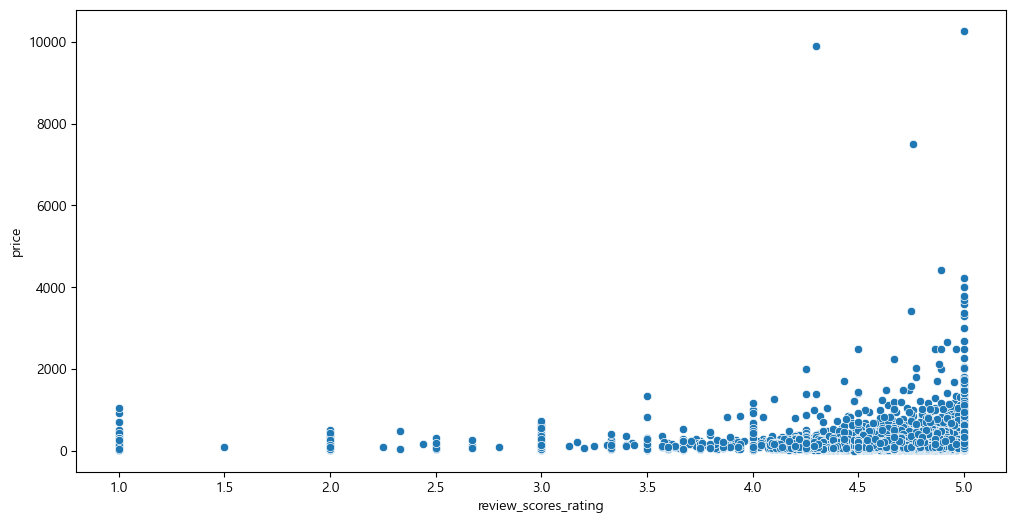

In [482]:
sns.scatterplot(x=test_df['review_scores_rating'], y=test_df['price'])
plt.show()

In [483]:
test_df['price'].corr(test_df['review_scores_accuracy'])

np.float64(0.03470980673763494)

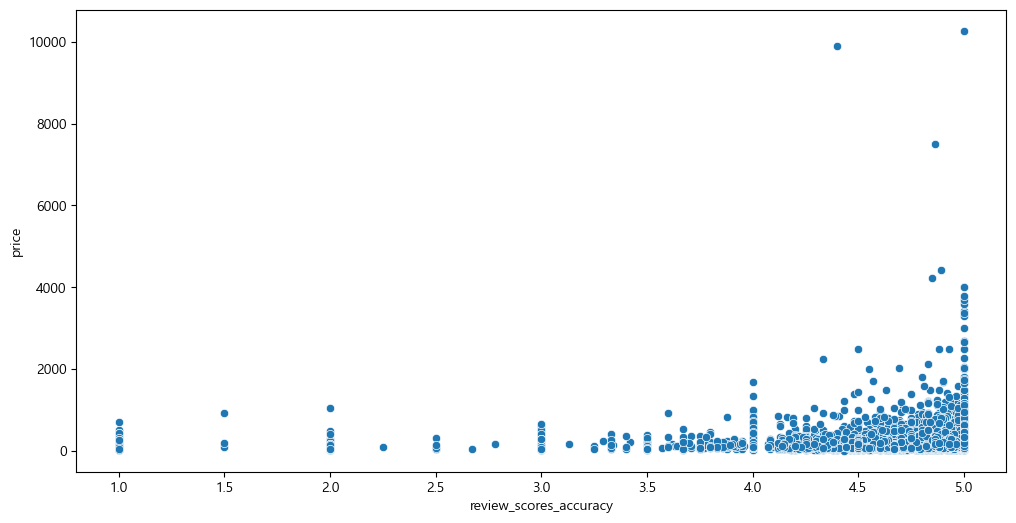

In [484]:
sns.scatterplot(x=test_df['review_scores_accuracy'], y=test_df['price'])
plt.show()

In [485]:
test_df['price'].corr(test_df['review_scores_cleanliness'])

np.float64(0.05582800182833005)

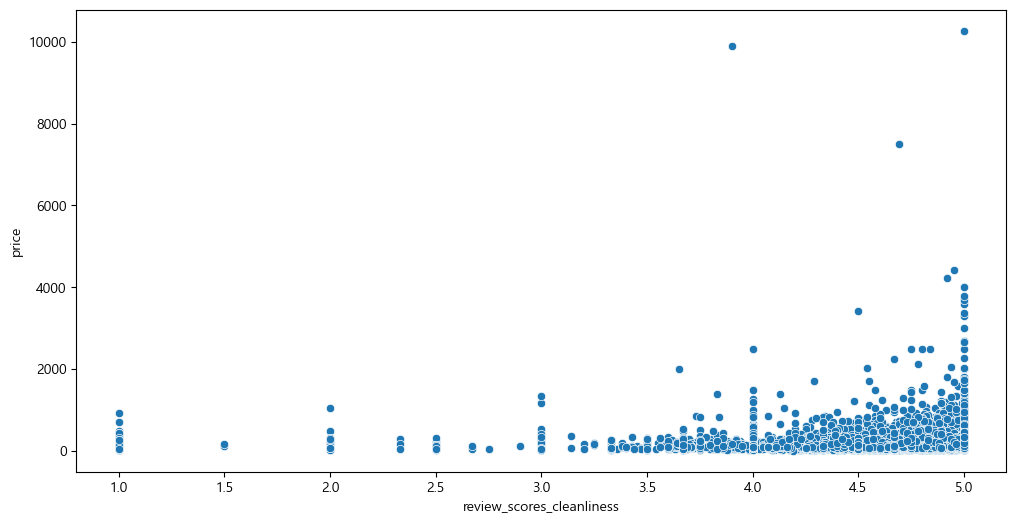

In [486]:
sns.scatterplot(x=test_df['review_scores_cleanliness'], y=test_df['price'])
plt.show()

In [487]:
test_df['price'].corr(test_df['review_scores_checkin'])

np.float64(0.02229354153866021)

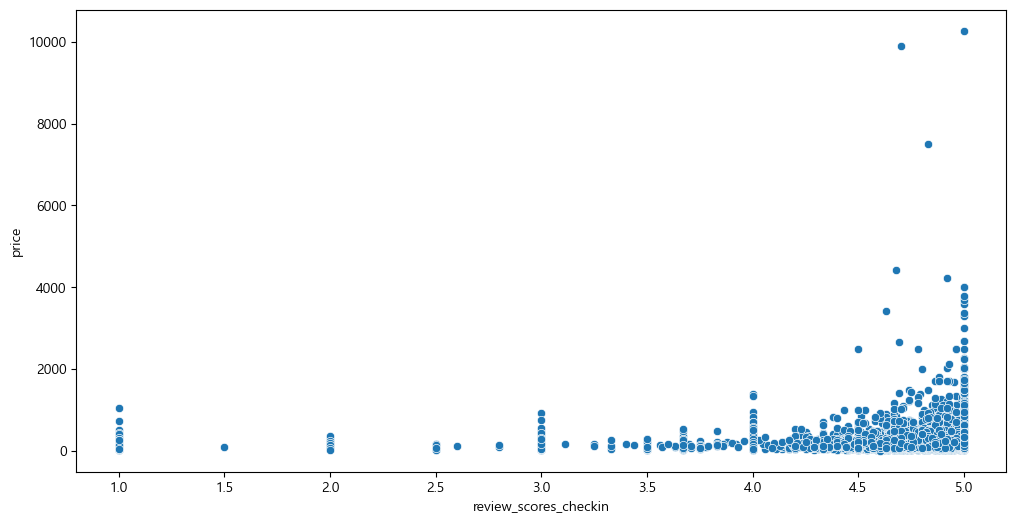

In [488]:
sns.scatterplot(x=test_df['review_scores_checkin'], y=test_df['price'])
plt.show()

In [489]:
test_df['price'].corr(test_df['review_scores_communication'])

np.float64(0.02376877847187377)

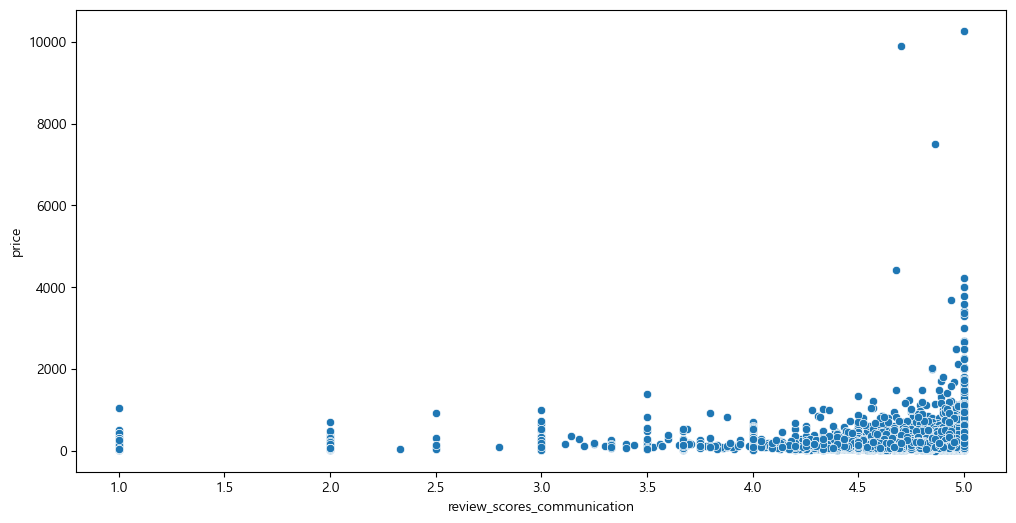

In [490]:
sns.scatterplot(x=test_df['review_scores_communication'], y=test_df['price'])
plt.show()

In [491]:
test_df['price'].corr(test_df['review_scores_location'])

np.float64(0.0858486200669148)

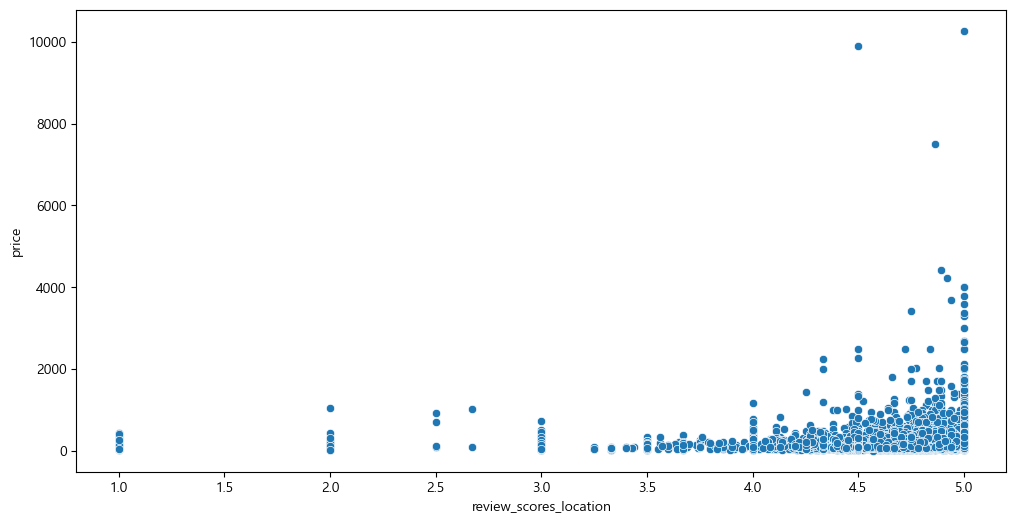

In [492]:
sns.scatterplot(x=test_df['review_scores_location'], y=test_df['price'])
plt.show()

In [493]:
test_df['price'].corr(test_df['review_scores_value'])

np.float64(0.012482731593204725)

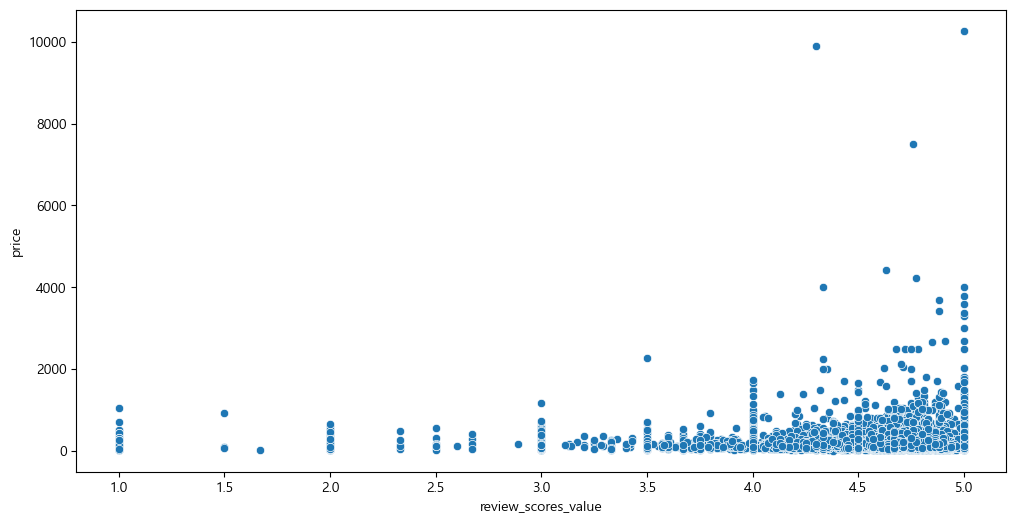

In [494]:
sns.scatterplot(x=test_df['review_scores_value'], y=test_df['price'])
plt.show()

In [495]:
test_df['instant_bookable'] = test_df['instant_bookable'].map({'t':1,'f':0})

In [496]:
test_df['instant_bookable']

0        0
1        0
2        0
3        0
4        0
        ..
22303    0
22304    0
22305    0
22306    1
22307    0
Name: instant_bookable, Length: 22305, dtype: int64

In [497]:
test_df['price'].corr(test_df['instant_bookable'])

np.float64(0.11605801994981908)

<Axes: xlabel='instant_bookable', ylabel='price'>

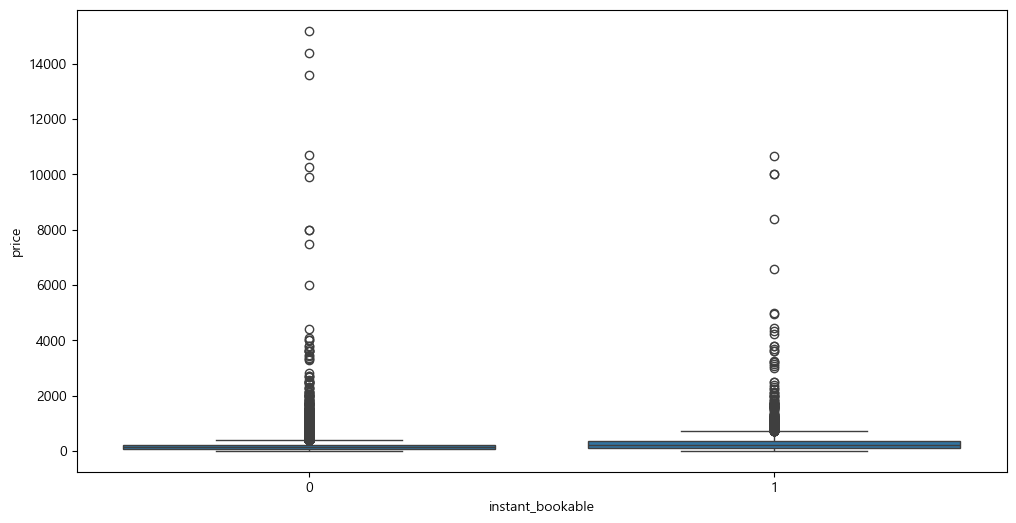

In [498]:
sns.boxplot(x=test_df['instant_bookable'], y=test_df['price'])

In [499]:
test_df['price'].corr(test_df['calculated_host_listings_count'])

np.float64(0.11511594423638581)

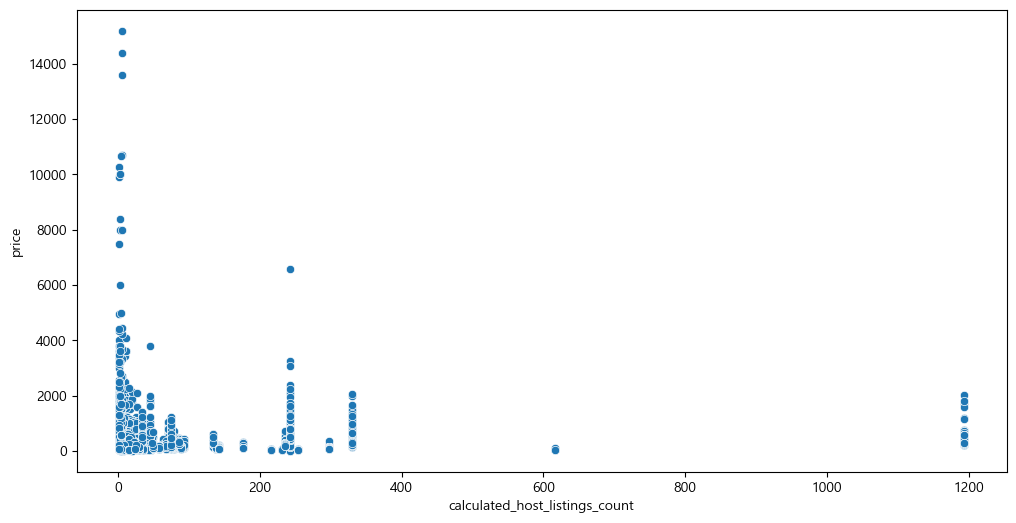

In [500]:
sns.scatterplot(x=test_df['calculated_host_listings_count'], y=test_df['price'])
plt.show()

In [501]:
test_df['price'].corr(test_df['calculated_host_listings_count_entire_homes'])

np.float64(0.12459035439006307)

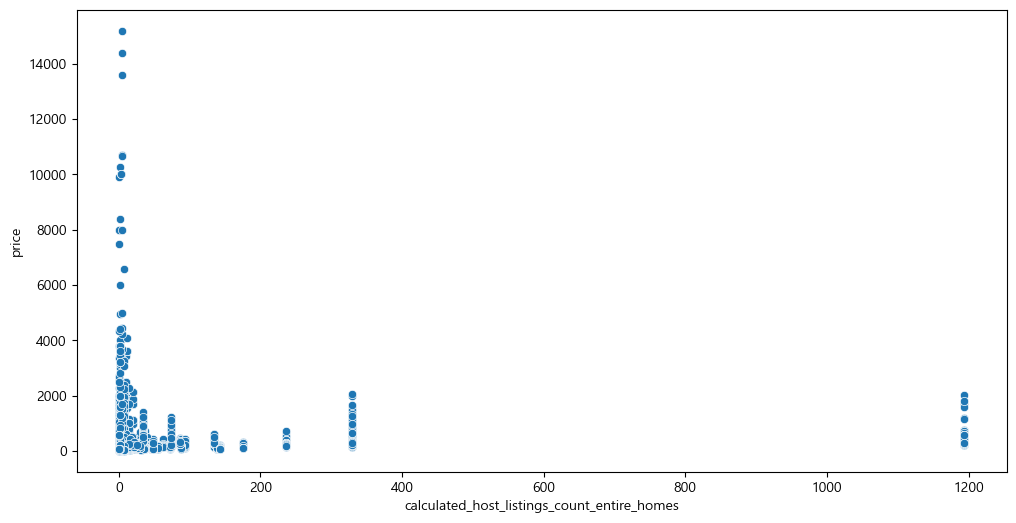

In [502]:
sns.scatterplot(x=test_df['calculated_host_listings_count_entire_homes'], y=test_df['price'])
plt.show()

In [503]:
test_df['price'].corr(test_df['calculated_host_listings_count_private_rooms'])

np.float64(-0.0754551168637336)

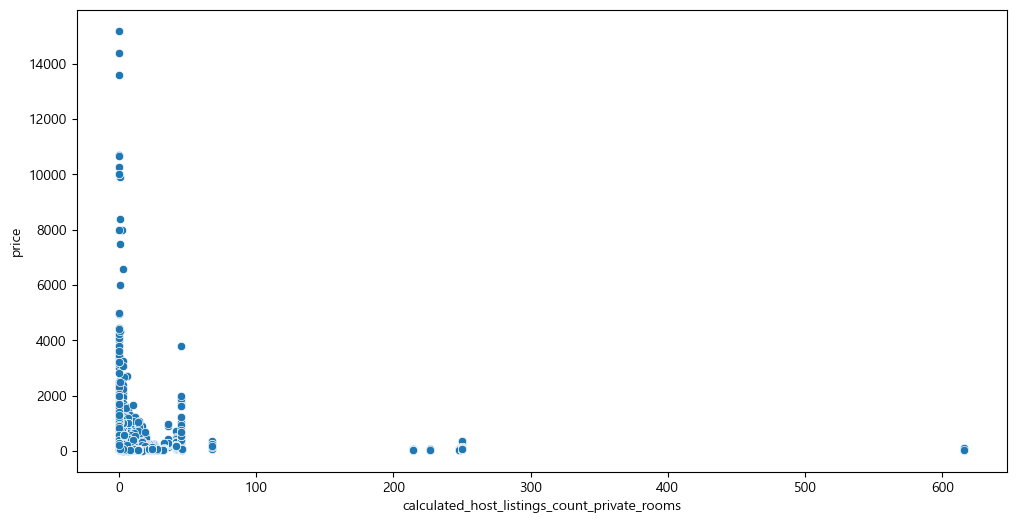

In [504]:
sns.scatterplot(x=test_df['calculated_host_listings_count_private_rooms'], y=test_df['price'])
plt.show()

In [505]:
test_df['price'].corr(test_df['calculated_host_listings_count_shared_rooms'])

np.float64(-0.031944033456751314)

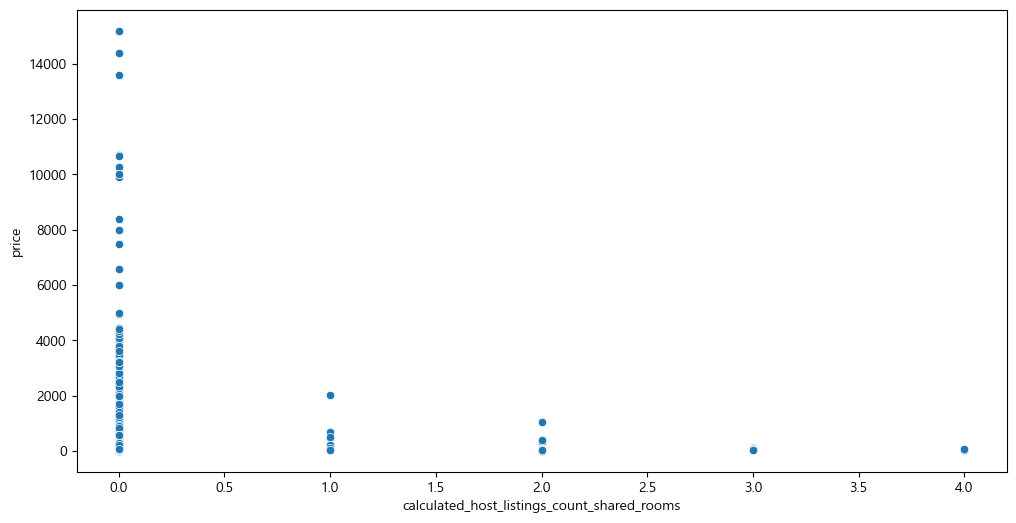

In [506]:
sns.scatterplot(x=test_df['calculated_host_listings_count_shared_rooms'], y=test_df['price'])
plt.show()

In [507]:
test_df['price'].corr(test_df['reviews_per_month'])

np.float64(-0.0117642208289792)

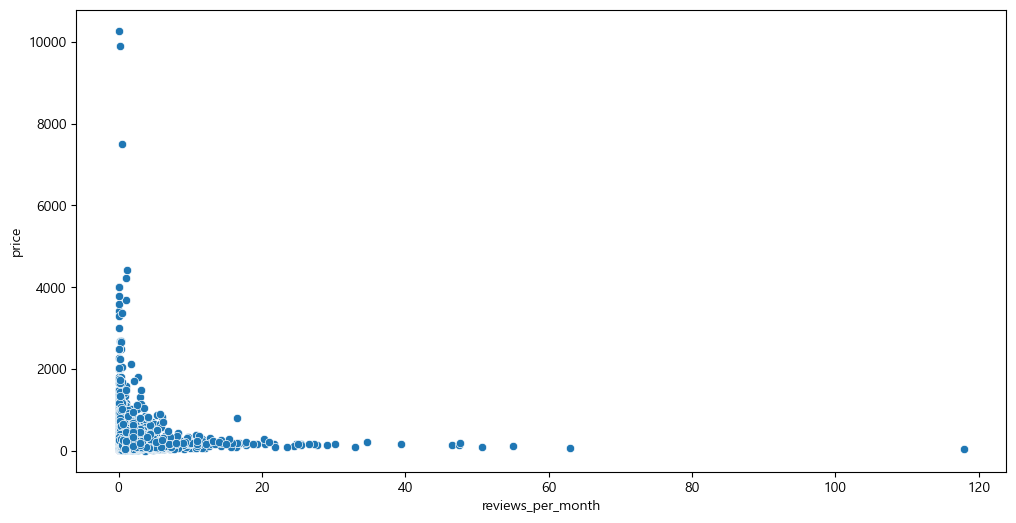

In [508]:
sns.scatterplot(x=test_df['reviews_per_month'], y=test_df['price'])
plt.show()

In [509]:
corr = test_df[['price',
'number_of_reviews_ltm',
'number_of_reviews_l30d',
'estimated_occupancy_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'instant_bookable',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month'
]].corr()['price'].sort_values(ascending=False)

corr

price                                           1.000000
calculated_host_listings_count_entire_homes     0.124590
instant_bookable                                0.116058
calculated_host_listings_count                  0.115116
review_scores_location                          0.085849
review_scores_cleanliness                       0.055828
review_scores_rating                            0.043957
review_scores_accuracy                          0.034710
review_scores_communication                     0.023769
review_scores_checkin                           0.022294
review_scores_value                             0.012483
reviews_per_month                              -0.011764
number_of_reviews_l30d                         -0.014649
number_of_reviews_ltm                          -0.022315
calculated_host_listings_count_shared_rooms    -0.031944
calculated_host_listings_count_private_rooms   -0.075455
estimated_occupancy_l365d                      -0.092091
Name: price, dtype: float64

In [510]:
type(corr)

pandas.Series

In [511]:
corr_heat = test_df[['price',
'number_of_reviews_ltm',
'number_of_reviews_l30d',
'estimated_occupancy_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'instant_bookable',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month'
]].corr()

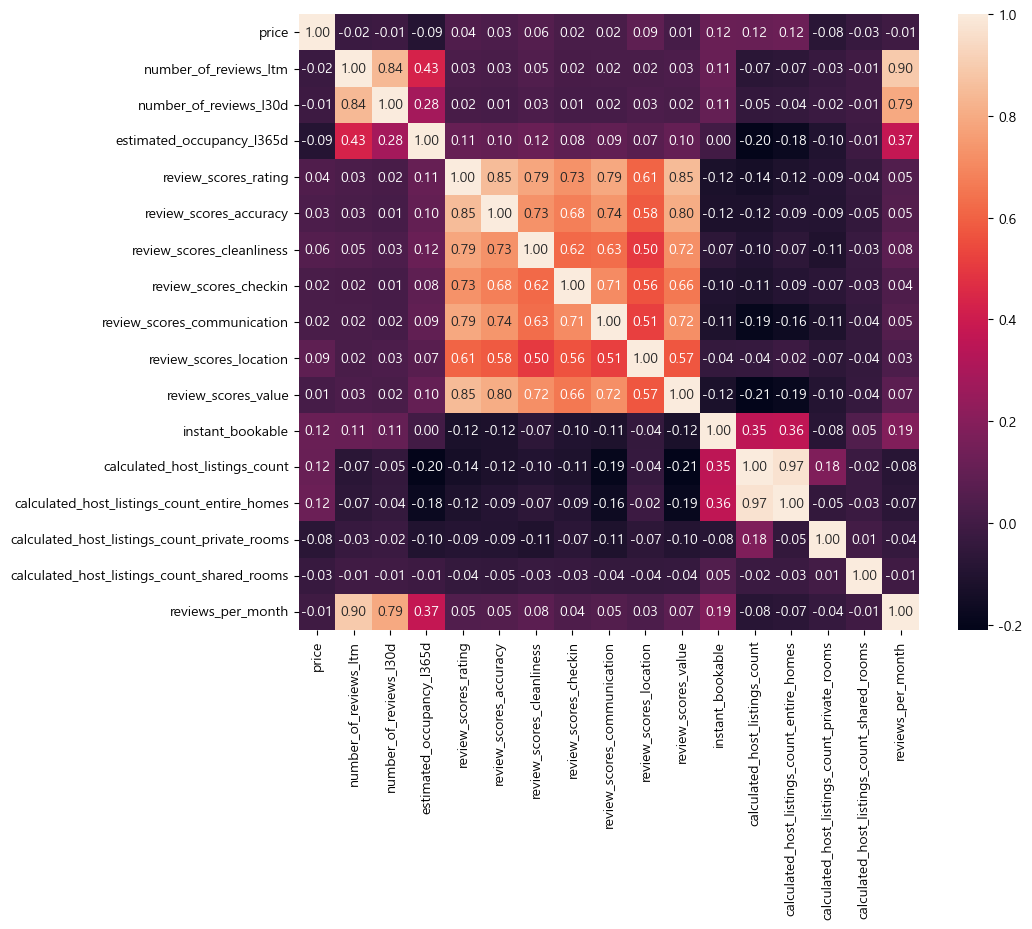

In [512]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_heat, annot=True, fmt='.2f')
plt.show()

In [513]:
test_df[['price','calculated_host_listings_count_entire_homes']].corr().round(2)

,price,calculated_host_listings_count_entire_homes
price,1.00,0.12
calculated_host_listings_count_entire_homes,0.12,1.00


<Axes: xlabel='calculated_host_listings_count_entire_homes', ylabel='price'>

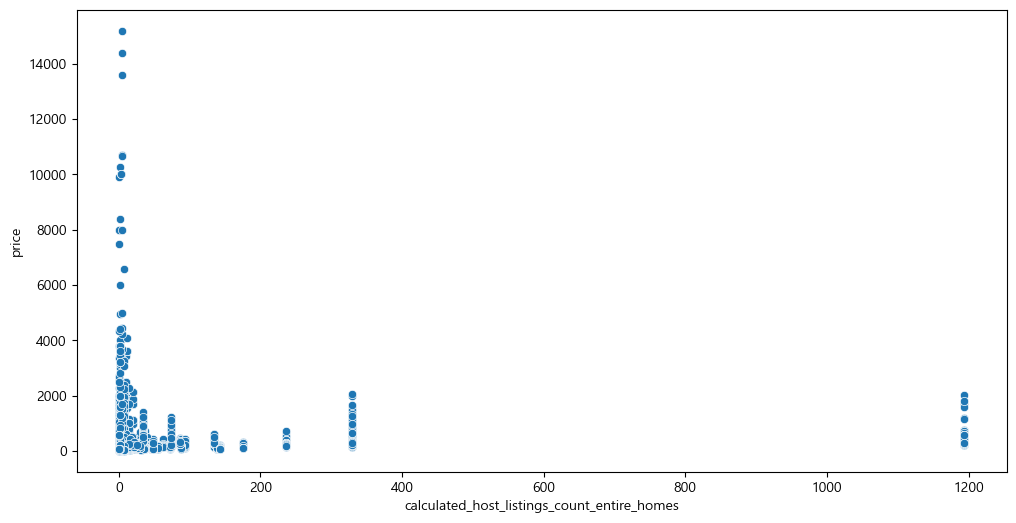

In [514]:
sns.scatterplot(x=test_df['calculated_host_listings_count_entire_homes'],y=test_df['price'])

In [515]:
test_df[['reviews_per_month']]

,reviews_per_month
0,0.05
1,0.58
2,0.28
3,1.36
4,1.54
...,...
22303,NaN
22304,NaN
22305,NaN
22306,NaN


In [516]:
test_df['reviews_per_month'].isna().sum()

np.int64(6795)

In [517]:
selected_cols =[
'id',
'name',
'description',
'host_id',
'host_since',
'host_response_time',
'host_response_rate',
'host_acceptance_rate',
'host_is_superhost',
'neighbourhood_cleansed',
'neighbourhood_group_cleansed',
'latitude',
'longitude',
'property_type',
'room_type',
'accommodates',
'bedrooms',
'beds',
'amenities',
'price',
'availability_365',
'number_of_reviews',
'number_of_reviews_ltm',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'calculated_host_listings_count',
'calculated_host_listings_count_entire_homes',
'calculated_host_listings_count_private_rooms',
'calculated_host_listings_count_shared_rooms',
'reviews_per_month']

In [518]:
df_clean = pd.read_csv("data/first_clean_data.csv")
clean = df_clean.copy()

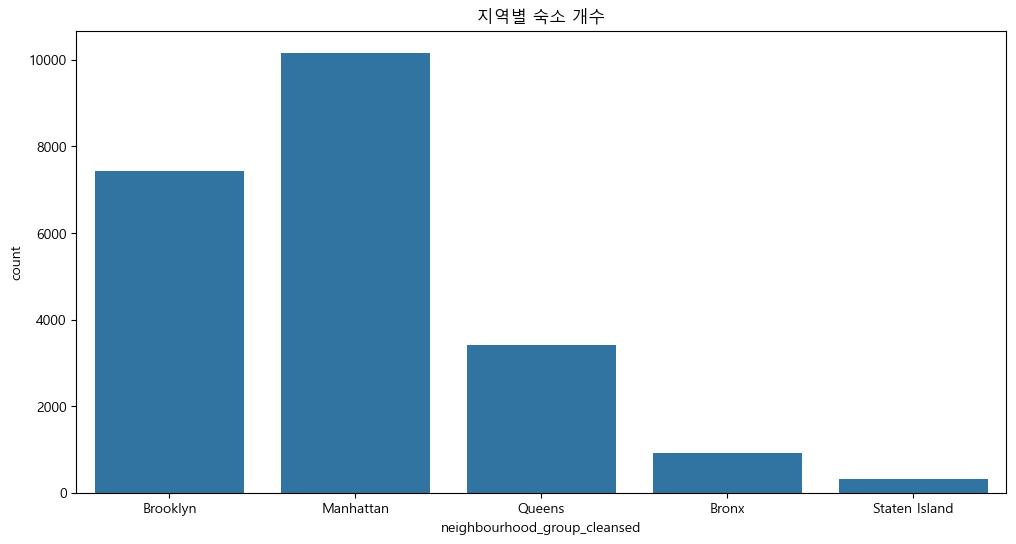

In [519]:
sns.countplot(data=clean, x='neighbourhood_group_cleansed') 
plt.title('지역별 숙소 개수')
plt.show()

In [520]:
pd.crosstab(clean['neighbourhood_group_cleansed'],clean['room_type']).reset_index()

room_type,neighbourhood_group_cleansed,Entire home/apt,Hotel room,Private room,Shared room
0,Bronx,370,0,541,0
1,Brooklyn,3772,17,3623,30
2,Manhattan,6928,340,2880,17
3,Queens,1408,8,1975,23
4,Staten Island,157,0,159,0


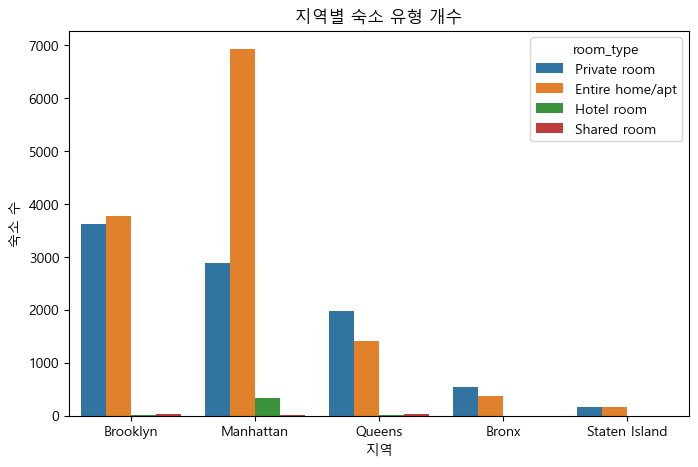

In [521]:
plt.figure(figsize=(8,5))
sns.countplot(data=clean, x='neighbourhood_group_cleansed', hue='room_type')
plt.title('지역별 숙소 유형 개수')
plt.xlabel('지역')
plt.ylabel('숙소 수')
plt.show()

In [522]:
pd.crosstab(clean['neighbourhood_group_cleansed'], clean['room_type'], normalize='index').round(2)

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_group_cleansed,,,,
Bronx,0.41,0.00,0.59,0.00
Brooklyn,0.51,0.00,0.49,0.00
Manhattan,0.68,0.03,0.28,0.00
Queens,0.41,0.00,0.58,0.01
Staten Island,0.50,0.00,0.50,0.00


In [523]:
ct = pd.crosstab(clean['neighbourhood_group_cleansed'], clean['room_type'], normalize='index').round(2)

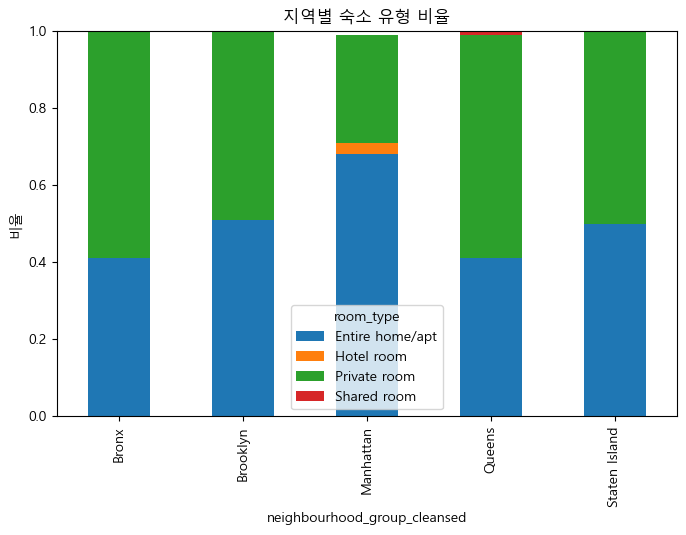

In [524]:
ct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("지역별 숙소 유형 비율")
plt.ylabel("비율")
plt.show()

In [525]:
clean['neighbourhood_group_cleansed'].value_counts(normalize=False)

neighbourhood_group_cleansed
Manhattan        10165
Brooklyn          7442
Queens            3414
Bronx              911
Staten Island      316
Name: count, dtype: int64

In [526]:
region = clean['neighbourhood_group_cleansed'].value_counts(normalize=True) * 100
region = region.round(2)

region

neighbourhood_group_cleansed
Manhattan        45.69
Brooklyn         33.45
Queens           15.35
Bronx             4.09
Staten Island     1.42
Name: proportion, dtype: float64

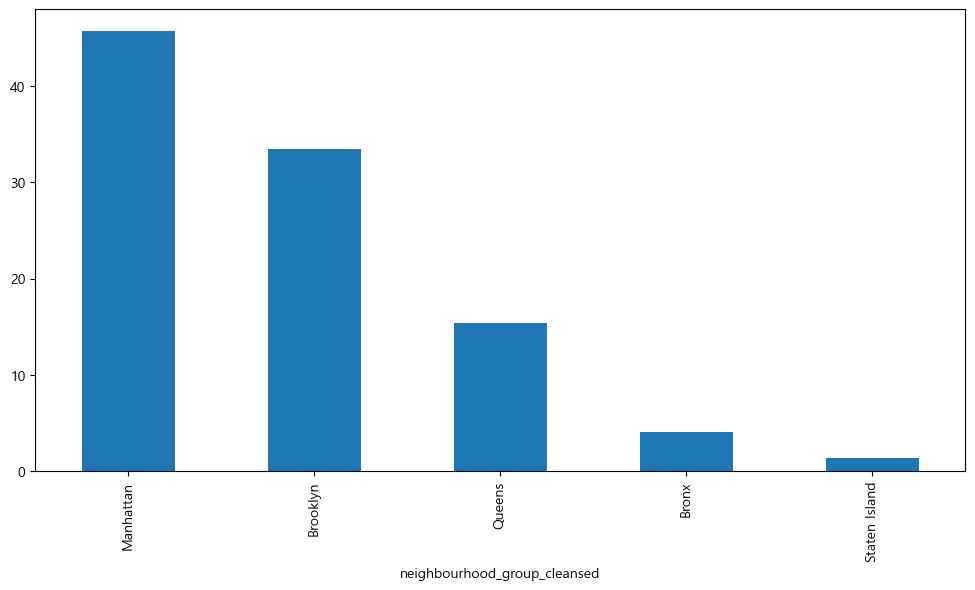

In [527]:
region.plot(kind='bar')
plt.show()

In [528]:
df_cleaned = pd.read_csv("data/first_clean_data.csv")
df['amenities']

0        ["Refrigerator", "Dishes and silverware", "Wif...
1        ["Oven", "Blender", "Luggage dropoff allowed",...
2        ["Portable fans", "Oven", "Baking sheet", "Fir...
3        ["Fire extinguisher", "Clothing storage: close...
4        ["Oven", "Rice maker", "Laundromat nearby", "L...
                               ...                        
22303    ["Air conditioning", "Carbon monoxide alarm", ...
22304    ["Air conditioning", "Carbon monoxide alarm", ...
22305    ["Air conditioning", "Carbon monoxide alarm", ...
22306    ["Oven", "Gym", "Blender", "Dedicated workspac...
22307    ["Air conditioning", "Carbon monoxide alarm", ...
Name: amenities, Length: 22308, dtype: str

In [529]:
cols = [
    'id','name','description','host_id','host_since','host_response_time','host_response_rate','host_acceptance_rate','host_is_superhost','neighbourhood_cleansed',
    'neighbourhood_group_cleansed','latitude','longitude','property_type','room_type','accommodates','bedrooms','beds','amenities','price','availability_365',
    'number_of_reviews','number_of_reviews_ltm','estimated_occupancy_l365d','estimated_revenue_l365d','review_scores_rating','review_scores_accuracy','review_scores_cleanliness',
    'review_scores_checkin','review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms', 'reviews_per_month'
]
df_sg = df[cols]

In [530]:
df_sg_cleaned = df_sg.copy()

In [531]:
mask = (df_sg_cleaned['review_scores_location'].isna()) & (df_sg_cleaned['review_scores_accuracy'].notna())
df_sg_cleaned.loc[mask, 'review_scores_location'] = 5.0

In [532]:
df_sg_cleaned.loc[(df['review_scores_location'].isna()) & (df['review_scores_accuracy'].notna()),'review_scores_location']

10849    5.0
Name: review_scores_location, dtype: float64

In [533]:
df_sh = df_sg_cleaned

In [534]:
df_sh['description'] = df_sh['description'].fillna('unknown')

In [535]:
df_sh['host_since'] = df_sh['host_since'].fillna('unknown')

In [536]:
mapping = {'within an hour': 4, 'within a few hours': 3, 'within a day': 2, 'a few days or more': 1}
df_sh['host_response_time'] = df_sh['host_response_time'].map(mapping)
# 3-1번 그러고 결측값들은 unknown으로 대체
df_sh['host_response_time'] = df_sh['host_response_time'].fillna(-1)

In [537]:
df_sh['host_response_rate'] = (df_sh['host_response_rate'].str.replace('%', '', regex=False).astype(float))

In [538]:
df_sh['host_response_rate']

0          NaN
1          NaN
2        100.0
3        100.0
4        100.0
         ...  
22303      NaN
22304    100.0
22305     94.0
22306     89.0
22307    100.0
Name: host_response_rate, Length: 22308, dtype: float64

In [539]:
df_sh['host_is_superhost'] = df_sh['host_is_superhost'].map({'t':True, 'f':False})
# 전처리 마지막 슈퍼호스트 결측치 unknown대체 이거부터 결측값 채워야 rate컬럼 결측 슈퍼호스트랑 일반호스트 중앙값채워지면서 nan이 안됨
df_sh['host_is_superhost'] = df_sh['host_is_superhost'].fillna('unknown')
# 호스트 응답률 데이터 변환
df_sh['host_acceptance_rate'] = (df_sh['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float))

In [540]:
# host_is_superhost 기준으로 그룹을 나누고 각 그룹의 host_acceptance_rate 중앙값으로 결측값을 대체
# 슈퍼호스트와 일반호스트 그룹을 나누어 각 그룹의 중앙값으로 host_acceptance_rate 결측을 채움.
df_sh['host_acceptance_rate'] = (
    df_sh.groupby('host_is_superhost')['host_acceptance_rate']
       .transform(lambda x: x.fillna(x.median()))
)

In [541]:
# bedrooms 전처리
df_sh = df_sh.dropna(subset=["bedrooms"])

In [542]:
# beds 전처리
# 룸 타입별로 중앙값으로 beds 결측값 채우기
df_sh["beds"] = df_sh["beds"].fillna(df_sh.groupby("room_type")["beds"].transform("median"))
df_sh["beds"].value_counts()

beds
1.0     13019
2.0      5135
3.0      1896
4.0       911
0.0       634
5.0       328
6.0       180
7.0        66
8.0        54
9.0        17
10.0        7
12.0        4
13.0        3
11.0        2
42.0        1
14.0        1
21.0        1
Name: count, dtype: int64

In [543]:
target_columns = list(df_cleaned.columns) 
if 'review_scores_rating' not in target_columns:
    target_columns.append('review_scores_rating')

# 2. 그 중 수치형 데이터만 추출
numeric_df = df_cleaned[target_columns].select_dtypes(include=['number'])

# 3. 스피어만 상관계수 계산 (이상치에 강함)
review_scores_rating_corr = numeric_df.corr(method='spearman')['review_scores_rating'].sort_values(ascending=False)

print("--- 평점과 상관관계가 높은 주요 변수 ---")
print(review_scores_rating_corr)

--- 평점과 상관관계가 높은 주요 변수 ---
review_scores_rating                            1.000000
review_scores_accuracy                          0.778852
review_scores_value                             0.711800
review_scores_cleanliness                       0.707056
review_scores_communication                     0.691476
review_scores_checkin                           0.647184
review_scores_location                          0.473748
id                                              0.129799
Unnamed: 0                                      0.129747
log_price                                       0.100145
price                                           0.100145
host_response_rate                              0.069837
bedrooms                                        0.059570
estimated_revenue_l365d                         0.041775
estimated_occupancy_l365d                       0.010973
longitude                                       0.008880
host_response_time                              0.001071
calc

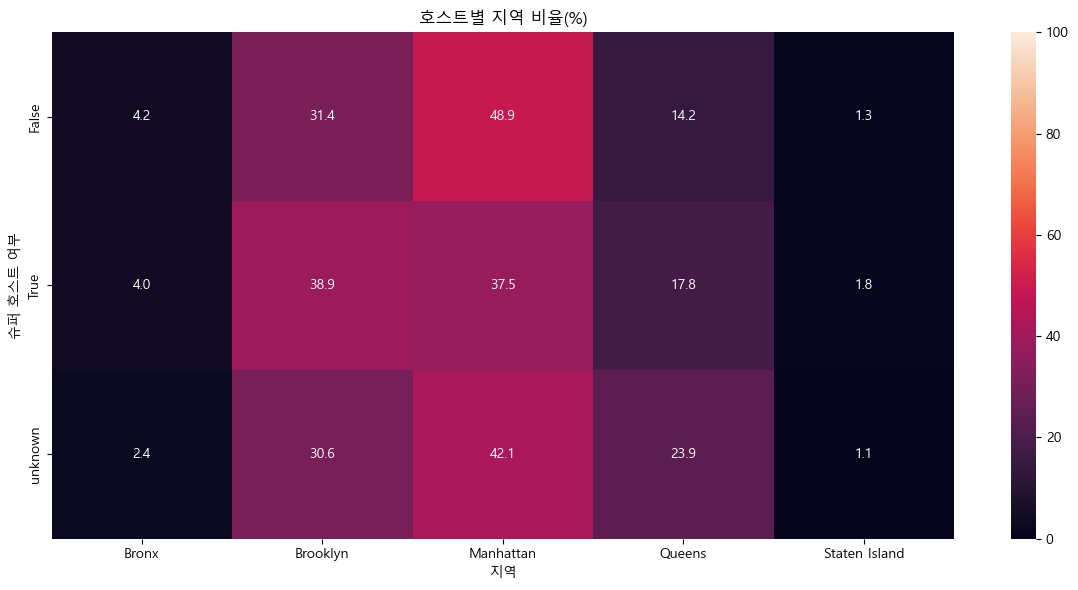

In [544]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct = pd.crosstab(df_cleaned["host_is_superhost"], df_cleaned["neighbourhood_group_cleansed"], normalize="index") * 100

# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("호스트별 지역 비율(%)")
plt.xlabel("지역")
plt.ylabel("슈퍼 호스트 여부")
plt.tight_layout()
plt.show()

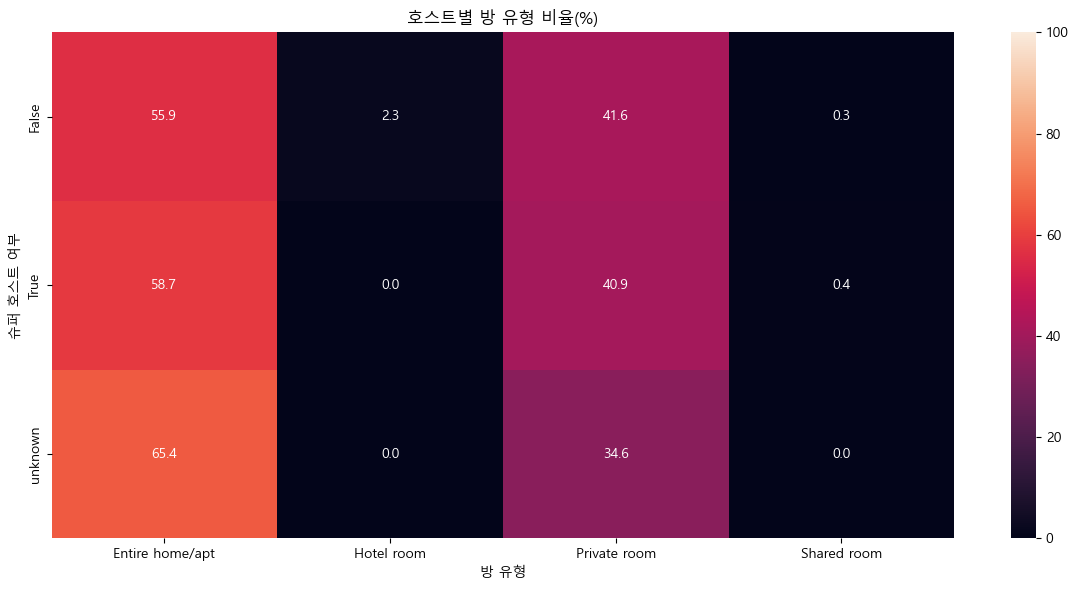

In [545]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct = pd.crosstab(df_cleaned["host_is_superhost"], df_cleaned["room_type"], normalize="index") * 100

# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("호스트별 방 유형 비율(%)")
plt.xlabel("방 유형")
plt.ylabel("슈퍼 호스트 여부")
plt.tight_layout()
plt.show()

In [546]:
import pandas as pd
df = pd.read_csv("data/first_clean_data.csv")
df

,Unnamed: 0,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22243,37429,1366333532374850165,Beautiful 1-Bed Apt in Harlem!,Welcome to your temporary home in the vibrant ...,40019013,2015-07-30,-1.0,-1.0,87.0,False,Harlem,Manhattan,40.813794,-73.952399,Private room in rental unit,Private room,1,1.0,1.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",72,358,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,4.290459
22244,37430,1366717321390111215,Private Room w/ Ensuite Bath H,Stylish Private Rooms w/ En-Suite Baths in Bro...,483056418,2022-10-10,4.0,100.0,80.0,True,Bedford-Stuyvesant,Brooklyn,40.685500,-73.919510,Private room in rental unit,Private room,2,1.0,0.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",58,363,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,0,24,0,NaN,4.077537
22245,37431,1366721904709517353,2 Bedroom on East Side,Located in the Murray Hill area and occupies a...,30283594,2015-03-30,4.0,94.0,99.0,False,Kips Bay,Manhattan,40.745290,-73.979380,Entire rental unit,Entire home/apt,5,2.0,3.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",299,99,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,48,0,0,NaN,5.703782
22246,37432,1366722692755341871,Stylish 2Bd near Bryant Park,Enjoy everything the city has to offer while l...,407304997,2021-06-15,4.0,89.0,100.0,False,Theater District,Manhattan,40.757133,-73.983124,Entire re

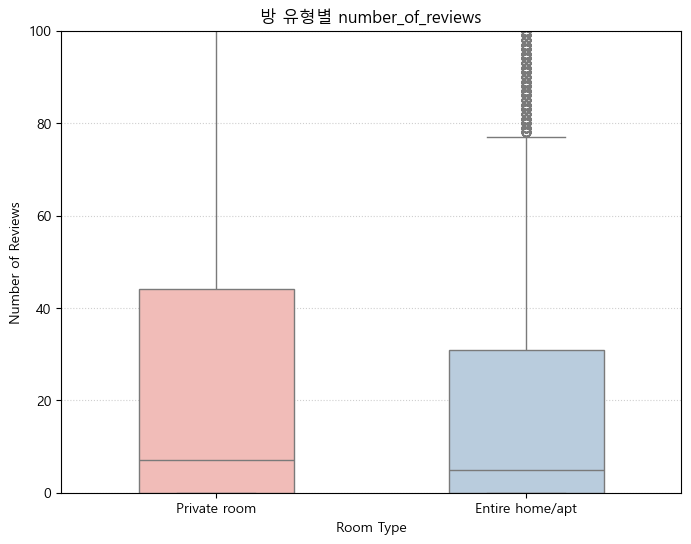

In [547]:
room_target_types = ['Entire home/apt', 'Private room']
room_filtered_df = df[df['room_type'].isin(room_target_types)]

plt.figure(figsize=(8, 6))
sns.boxplot(x='room_type', y='number_of_reviews', data=room_filtered_df, 
            palette='Pastel1', width=0.5)

plt.title('방 유형별 number_of_reviews')
plt.xlabel('Room Type')
plt.ylabel('Number of Reviews')
plt.ylim(0,100)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.show()

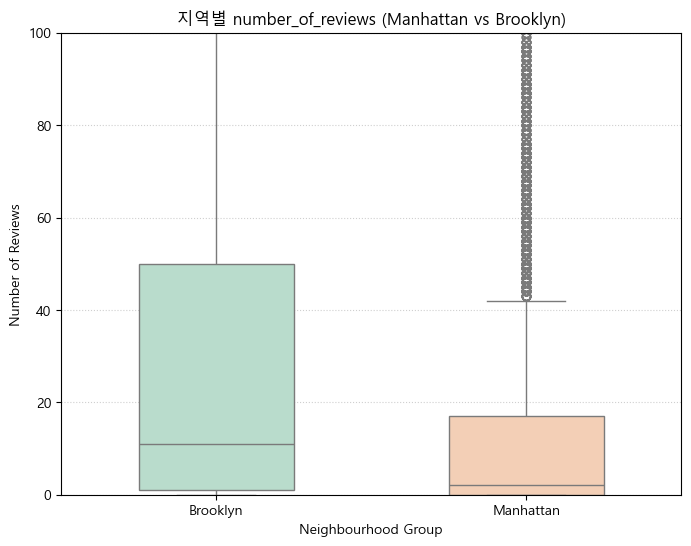

In [548]:
location_target_types = ['Manhattan', 'Brooklyn']
location_filtered_df = df[df['neighbourhood_group_cleansed'].isin(location_target_types)]

plt.figure(figsize=(8, 6))

sns.boxplot(x='neighbourhood_group_cleansed', y='number_of_reviews', data=location_filtered_df, 
            palette='Pastel2', width=0.5)

plt.title('지역별 number_of_reviews (Manhattan vs Brooklyn)')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Reviews')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.show()

In [549]:
clean_df = pd.read_csv("data/first_clean_data.csv")

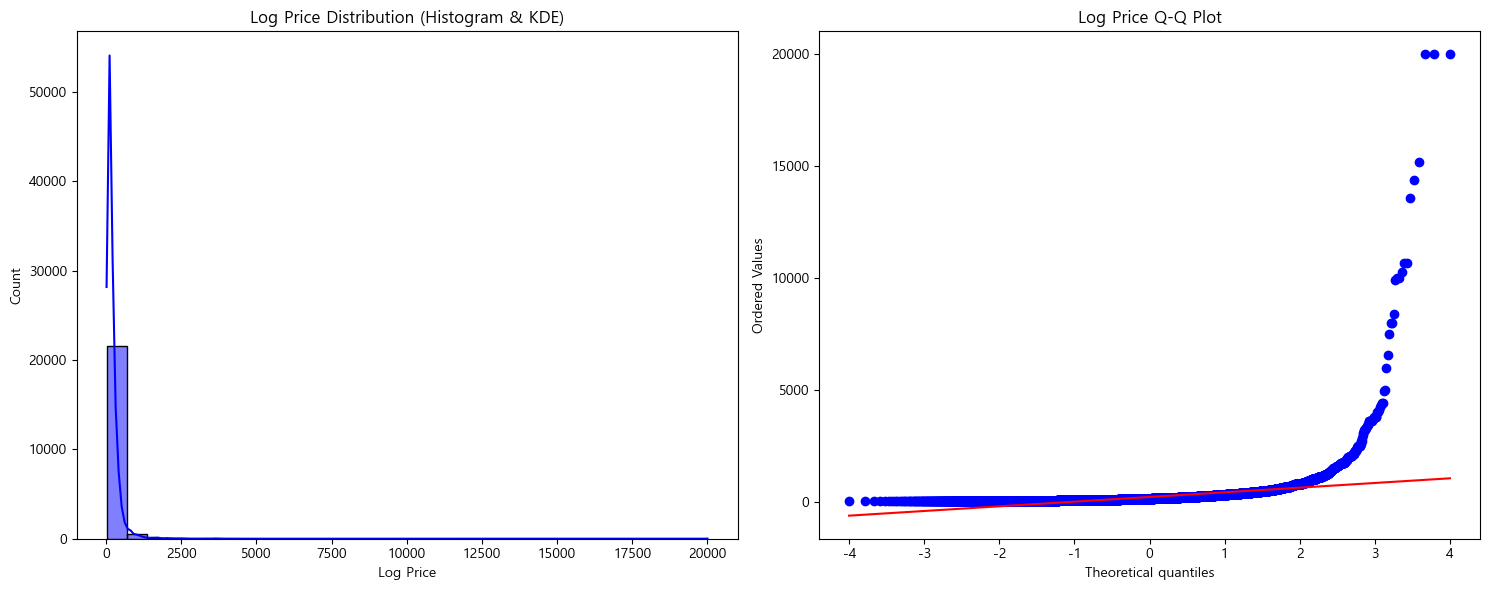

In [550]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(clean_df['price'], kde=True, color='blue', bins=30, ax=axes[0])
axes[0].set_title('Log Price Distribution (Histogram & KDE)')
axes[0].set_xlabel('Log Price')

stats.probplot(clean_df['price'], dist="norm", plot=axes[1])
axes[1].set_title('Log Price Q-Q Plot')

plt.tight_layout()
plt.show()

Entire Home 데이터 개수: 12635
Private Room 데이터 개수: 9178


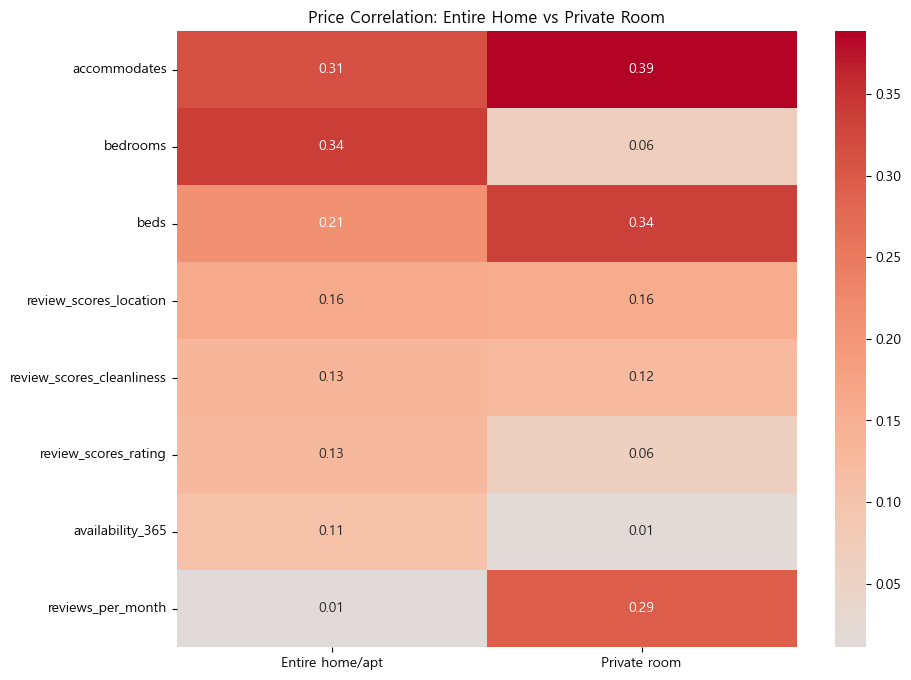

In [551]:
target_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 
    'review_scores_location', 'review_scores_cleanliness', 
    'review_scores_rating', 'availability_365', 'reviews_per_month'
]

private_df = clean_df[clean_df['room_type'] == 'Private room'][target_cols]
entire_df = clean_df[clean_df['room_type'] == 'Entire home/apt'][target_cols]

# 데이터 개수 확인 (신뢰도 체크)
print(f"Entire Home 데이터 개수: {len(entire_df)}")
print(f"Private Room 데이터 개수: {len(private_df)}")

# 3. 그룹별 스피어만 상관계수 계산
private_corr = private_df.corr(method='spearman')['price'].rename('Private room')
entire_corr = entire_df.corr(method='spearman')['price'].rename('Entire home/apt')

# 4. 결과 합치기
comparison_df = pd.concat([entire_corr, private_corr], axis=1).drop('price') # 'price' 자기 자신은 제외

# 5. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Price Correlation: Entire Home vs Private Room')
plt.show()

In [552]:
import pandas as pd
from scipy import stats

# 데이터 필터링 (Private room vs Entire home/apt)
private_room = df[df['room_type'] == 'Private room']
entire_home = df[df['room_type'] == 'Entire home/apt']

# 수용 인원(accommodates) 데이터 추출
group_p = private_room['accommodates']
group_e = entire_home['accommodates']

In [553]:
# Kolmogorov-Smirnov 검정 (표본이 많을 때 유리)
ks_p = stats.kstest(group_p, 'norm')
ks_e = stats.kstest(group_e, 'norm')

print(f"Private Room 정규성 p-value: {ks_p.pvalue}")
print(f"Entire Home 정규성 p-value: {ks_e.pvalue}")

Private Room 정규성 p-value: 0.0
Entire Home 정규성 p-value: 0.0


In [554]:
# Levene 검정 (중앙값 기준)
levene_test = stats.levene(group_p, group_e, center='median')
print(f"등분산성 p-value: {levene_test.pvalue}")

등분산성 p-value: 0.0


In [555]:
# 정규성 및 등분산성 결과에 따른 자동 선택 예시
is_normal = (ks_p.pvalue > 0.05) and (ks_e.pvalue > 0.05)
is_equal_var = (levene_test.pvalue > 0.05)

if is_normal:
    if is_equal_var:
        # 1. 독립표본 t-검정
        result = stats.ttest_ind(group_p, group_e)
        print("Student's t-test 수행:", result)
    else:
        # 2. Welch's t-test
        result = stats.ttest_ind(group_p, group_e, equal_var=False)
        print("Welch's t-test 수행:", result)
else:
    # 3. Mann-Whitney U test (비모수 검정)
    result = stats.mannwhitneyu(group_p, group_e, alternative='two-sided')
    print("Mann-Whitney U test 수행:", result)

Mann-Whitney U test 수행: MannwhitneyuResult(statistic=np.float64(23067773.0), pvalue=np.float64(0.0))


In [556]:
from scipy import stats

# 두 집단 설정 (예시 변수명)
group_p = df[df['room_type'] == 'Private room']['accommodates']
group_e = df[df['room_type'] == 'Entire home/apt']['accommodates']

# 맨-휘트니 U 검정 수행
u_stat, p_val = stats.mannwhitneyu(group_p, group_e, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat}")
print(f"p-value: {p_val}")

if p_val < 0.05:
    print("결론: 두 숙소 유형 간 수용 인원(accommodates)은 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결론: 두 숙소 유형 간 수용 인원의 차이가 통계적으로 유의미하지 않습니다.")

Mann-Whitney U statistic: 23067773.0
p-value: 0.0
결론: 두 숙소 유형 간 수용 인원(accommodates)은 통계적으로 유의미한 차이가 있습니다.


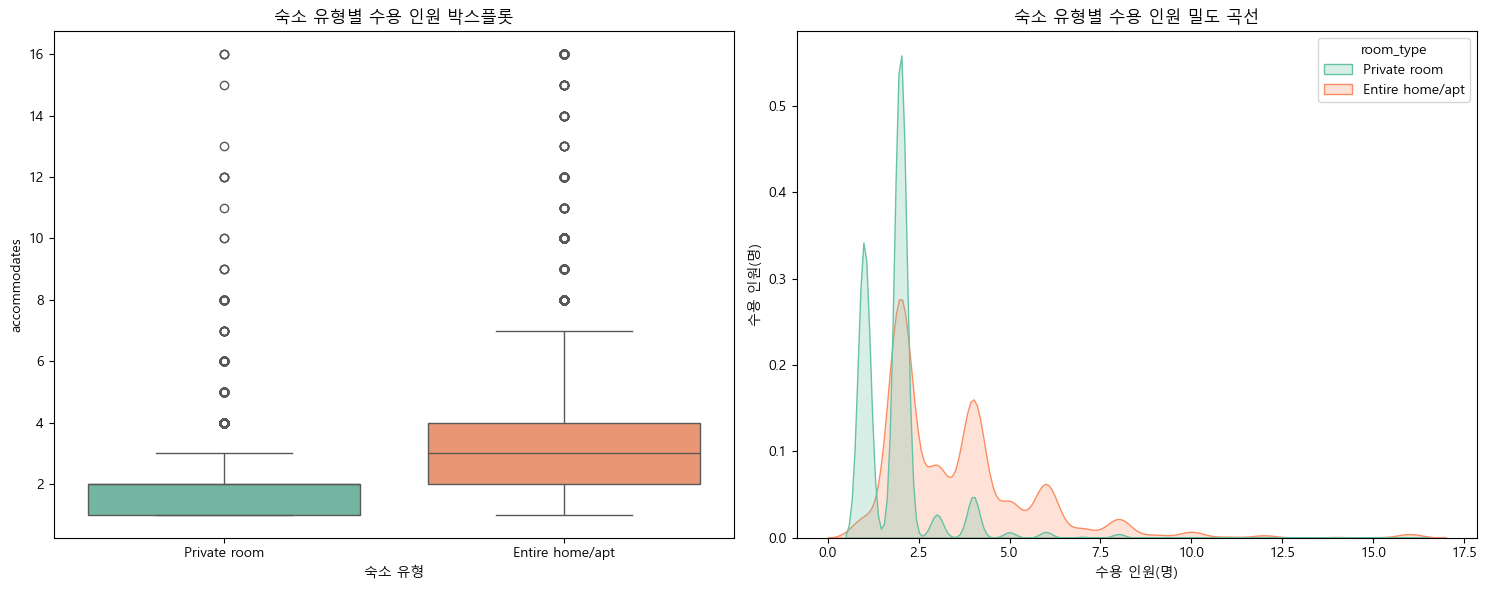

In [557]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' 

# 시각화를 위한 필터링 데이터 준비
plot_data = df[df['room_type'].isin(['Private room', 'Entire home/apt'])]

# 시각화 영역 설정 (2개의 서브플롯)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot: 중앙값과 이상치 확인
sns.boxplot(x='room_type', y='accommodates', data=plot_data, ax=axes[0], palette='Set2')
axes[0].set_title('숙소 유형별 수용 인원 박스플롯')
axes[0].set_xlabel('숙소 유형')
axes[1].set_ylabel('수용 인원(명)')

# 2. KDE Plot: 분포의 밀도 확인
sns.kdeplot(data=plot_data, x='accommodates', hue='room_type', fill=True, ax=axes[1], palette='Set2')
axes[1].set_title('숙소 유형별 수용 인원 밀도 곡선')
axes[1].set_xlabel('수용 인원(명)')

plt.tight_layout()
plt.show()

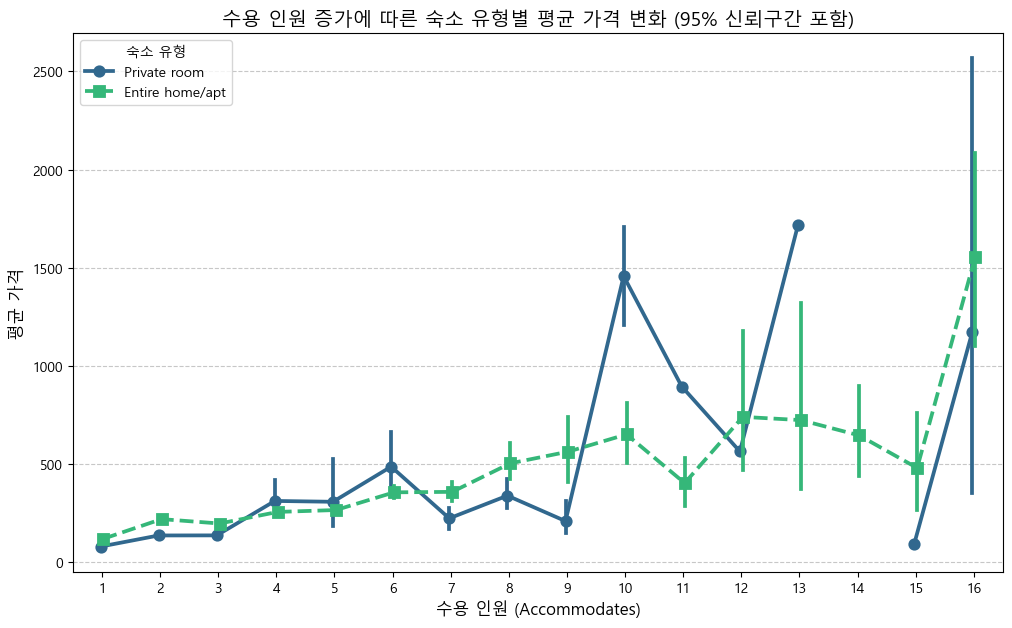

In [558]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비 (가독성을 위해 수용 인원 1~6명까지만 제한해서 보는 것이 좋습니다)
plot_df = df[df['room_type'].isin(['Private room', 'Entire home/apt'])]
plot_df = plot_df[plot_df['accommodates'] <= 16]

plt.figure(figsize=(12, 7))

# 포인트 플롯 생성
sns.pointplot(data=plot_df, x='accommodates', y='price', hue='room_type', 
              dodge=True, markers=['o', 's'], linestyles=['-', '--'], palette='viridis')

plt.title('수용 인원 증가에 따른 숙소 유형별 평균 가격 변화 (95% 신뢰구간 포함)', fontsize=14)
plt.xlabel('수용 인원 (Accommodates)', fontsize=12)
plt.ylabel('평균 가격', fontsize=12)
plt.legend(title='숙소 유형')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()